In [1]:
import math
import pickle as pkl
import warnings
import gc
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import seaborn as sns
import torch

import pandas as pd

from emle.models import EMLE
from emle.train._utils import pad_to_max
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [2]:
warnings.filterwarnings("ignore")
color_by_z = {1: "grey", 6: "cyan", 7: "blue", 8: "red", 16: "yellow"}
ANGSTROM_TO_BOHR = 1.8897259886
HARTREE_TO_KJ_MOL = 2625.5

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

### Load Data

In [4]:
data = pkl.load(
    open(
        "process_trajs/processed_traj_data_WAT.pkl",
        "rb",
    )
)

CUT_OFF = 12.0
stride = 1


# Get WAT data
z = pad_to_max(data["z"]).to(device=device, dtype=torch.long)[::stride]
xyz_qm = pad_to_max(data["xyz_qm"]).to(device=device, dtype=dtype)[::stride]
xyz_mm = pad_to_max(data["xyz_mm"]).to(device=device, dtype=dtype)[::stride]
charges_mm = pad_to_max(data["charges_mm"]).to(device=device, dtype=dtype)[::stride]

# Compute per-frame box volumes and total MM atom counts BEFORE cutoff
_BOHR3 = ANGSTROM_TO_BOHR**3
box_wat = torch.tensor(np.stack(data["box"]), device=device, dtype=dtype)[::stride]
box_vol_wat = (box_wat[:, 0] * box_wat[:, 1] * box_wat[:, 2]) * _BOHR3  # Bohr^3
n_mm_total_wat = (
    (charges_mm != 0).sum(dim=1).to(dtype=dtype)
)  # total MM atoms per frame

# Only keep MM atoms that are within 12 A of any QM atom
dists = torch.cdist(xyz_qm, xyz_mm)
mask_mm = (dists <= CUT_OFF).any(dim=1)

xyz_mm_list = []
charges_mm_list = []
for i in range(xyz_qm.shape[0]):
    xyz_mm_list.append(xyz_mm[i][mask_mm[i]])
    charges_mm_list.append(charges_mm[i][mask_mm[i]])
xyz_mm = pad_to_max(xyz_mm_list)
charges_mm = pad_to_max(charges_mm_list)

# Get CHX data
data_chx = pkl.load(open("process_trajs/processed_traj_data_CHX.pkl", "rb"))

z_chx = pad_to_max(data_chx["z"]).to(device=device, dtype=torch.long)[::stride]
xyz_qm_chx = pad_to_max(data_chx["xyz_qm"]).to(device=device, dtype=dtype)[::stride]
xyz_mm_chx = pad_to_max(data_chx["xyz_mm"]).to(device=device, dtype=dtype)[::stride]
charges_mm_chx = pad_to_max(data_chx["charges_mm"]).to(device=device, dtype=dtype)[
    ::stride
]

# Compute per-frame box volumes and total MM atom counts BEFORE cutoff
box_chx = torch.tensor(np.stack(data_chx["box"]), device=device, dtype=dtype)[::stride]
box_vol_chx = (box_chx[:, 0] * box_chx[:, 1] * box_chx[:, 2]) * _BOHR3  # Bohr^3
n_mm_total_chx = (
    (charges_mm_chx != 0).sum(dim=1).to(dtype=dtype)
)  # total MM atoms per frame

# Only keep MM atoms that are within 12 A of any QM atom
dists_chx = torch.cdist(xyz_qm_chx, xyz_mm_chx)
mask_mm_chx = (dists_chx <= CUT_OFF).any(dim=1)

xyz_mm_chx_list = []
charges_mm_chx_list = []
for i in range(xyz_qm_chx.shape[0]):
    xyz_mm_chx_list.append(xyz_mm_chx[i][mask_mm_chx[i]])
    charges_mm_chx_list.append(charges_mm_chx[i][mask_mm_chx[i]])
xyz_mm_chx = pad_to_max(xyz_mm_chx_list)
charges_mm_chx = pad_to_max(charges_mm_chx_list)

In [5]:
def pad_two(a, b):
    """Pad tensors a and b along dim=1 to the same length."""
    import torch.nn.functional as F

    L = max(a.shape[1], b.shape[1])
    pad_a = L - a.shape[1]
    pad_b = L - b.shape[1]

    if a.dim() == 2:
        pa = F.pad(a, (0, pad_a))
    else:
        pa = F.pad(a, (0, 0, 0, pad_a))

    if b.dim() == 2:
        pb = F.pad(b, (0, pad_b))
    else:
        pb = F.pad(b, (0, 0, 0, pad_b))

    return pa, pb


z, z_chx = pad_two(z, z_chx)
xyz_qm, xyz_qm_chx = pad_two(xyz_qm, xyz_qm_chx)
xyz_mm, xyz_mm_chx = pad_two(xyz_mm, xyz_mm_chx)
charges_mm, charges_mm_chx = pad_two(charges_mm, charges_mm_chx)

In [6]:
# Cat datasets and subsample
stride = 1

z = torch.cat([z, z_chx], dim=0)[::stride]
xyz_qm = torch.cat([xyz_qm, xyz_qm_chx], dim=0)[::stride]
xyz_mm = torch.cat([xyz_mm, xyz_mm_chx], dim=0)[::stride]
charges_mm = torch.cat([charges_mm, charges_mm_chx], dim=0)[::stride]
q_mol = torch.zeros(z.shape[0], device=device, dtype=dtype)

# Concat and stride per-frame box volumes and total MM atom counts
box_vol = torch.cat([box_vol_wat, box_vol_chx], dim=0)[::stride].to(device)
n_mm_total = torch.cat([n_mm_total_wat, n_mm_total_chx], dim=0)[::stride].to(device)

print(f"Total number of structures: {z.shape[0]}")

Total number of structures: 8000


### Assign TIP3P and CHX LJ Parameters

In [7]:
# TIP3P LJ Parameters
# O_sigma = 3.1507 Å, O_epsilon = 0.1521 kcal/mol
# H_sigma = 1.0 Å, H_epsilon = 0.0 kcal/mol
O_sigma = 3.1507 * ANGSTROM_TO_BOHR
O_epsilon = 0.1521 * 4.184 / HARTREE_TO_KJ_MOL
H_sigma = 1.0 * ANGSTROM_TO_BOHR
H_epsilon = 0.0

sigma_mm = charges_mm.clone()
sigma_mm[charges_mm == -0.834] = O_sigma
sigma_mm[charges_mm == 0.417] = H_sigma

epsilon_mm = charges_mm.clone()
epsilon_mm[charges_mm == -0.834] = O_epsilon
epsilon_mm[charges_mm == 0.417] = H_epsilon

# OpenFF-2.0.0 LJ Parameters
# C_sigma (n16) = 3.37 Å, O_epsilon = 0.1088406109251 kcal/mol
# H_sigma (n2) = 2.64 Å, H_epsilon = 0.01577948280971 kcal/mol
C_sigma_chx = 3.37953176162662 * ANGSTROM_TO_BOHR
C_epsilon_chx = 0.1088406109251 * 4.184 / HARTREE_TO_KJ_MOL
H_sigma_chx = 2.6445434132681245 * ANGSTROM_TO_BOHR
H_epsilon_chx = 0.01577948280971 * 4.184 / HARTREE_TO_KJ_MOL

C_sigma_chx = torch.nn.Parameter(
    torch.tensor(C_sigma_chx, device=device, dtype=dtype), requires_grad=False
)
C_epsilon_chx = torch.nn.Parameter(
    torch.tensor(C_epsilon_chx, device=device, dtype=dtype), requires_grad=True
)

sigma_mm[charges_mm == -0.0764] = C_sigma_chx
sigma_mm[charges_mm == 0.0382] = H_sigma_chx

epsilon_mm[charges_mm == -0.0764] = C_epsilon_chx
epsilon_mm[charges_mm == 0.0382] = H_epsilon_chx

# Now pad adding 0s for the QM atoms
num_qm_atoms = z.shape[1]
sigma_mm = torch.cat(
    [
        torch.zeros((sigma_mm.shape[0], num_qm_atoms), device=device, dtype=dtype),
        sigma_mm,
    ],
    dim=1,
)
epsilon_mm = torch.cat(
    [
        torch.zeros((epsilon_mm.shape[0], num_qm_atoms), device=device, dtype=dtype),
        epsilon_mm,
    ],
    dim=1,
)

# Get idx_mm
atom_indices = (
    torch.arange(charges_mm.shape[1])
    .unsqueeze(0)
    .expand(*charges_mm.shape)
    .to(device=device, dtype=torch.long)
)

idx_mm = torch.where(charges_mm != 0.0, atom_indices + num_qm_atoms, 0)
row_ids = (
    torch.arange(idx_mm.shape[0]).unsqueeze(-1).to(device=device, dtype=torch.long)
)
row_ids = row_ids.expand(-1, idx_mm.shape[1]).unsqueeze(-1)
idx_mm = torch.cat([row_ids, idx_mm.unsqueeze(-1)], dim=-1)

# Recreate nagl_params dictionary
nagl_params = {
    "lj_sigma_mm": sigma_mm,
    "lj_eps_mm": epsilon_mm,
}

# Index MM LJ parameters by idx_mm (needed for LRC and LJ energy)
lj_sigma_mm = nagl_params["lj_sigma_mm"].clone()
lj_sigma_mm = lj_sigma_mm[idx_mm[..., 0], idx_mm[..., 1]]
lj_eps_mm = nagl_params["lj_eps_mm"].clone()
lj_eps_mm = lj_eps_mm[idx_mm[..., 0], idx_mm[..., 1]]

### Create EMLE model

In [8]:
model = scipy.io.loadmat(
    "../fit_xdm_moments_reference/ligand_patched_static_only_xdm.mat"
)
model["sigma_scale_ref"] = np.ones_like(model["c6_ref"])
ones_file = "ligand_patched_static_only_xdm_sigma_ones.mat"
scipy.io.savemat(ones_file, model)

In [9]:
emle = EMLE(
    model=ones_file,
    device=device,
    dtype=dtype,
    alpha_mode="reference",
    dispersion_mode="lj",
    nagl_params=nagl_params,
)
emle_base = emle._emle_base

### Fine-tune the Fedorov relation via Zwanzig reweighting

In [10]:
def dG(energies, beta):
    """Compute solvation free energy using Zwanzig equation."""
    return -(1 / beta) * torch.logsumexp(-beta * energies, dim=1) + (
        1 / beta
    ) * torch.log(torch.tensor(energies.shape[1], dtype=torch.float32))

In [11]:
def get_lj_parameters(c6, alpha, sigma_scale):
    """
    Calculate Lennard-Jones sigma and epsilon parameters from C6 and polarizabilities.

    Uses empirical relationships to convert C6 dispersion coefficients and
    polarizabilities into Lennard-Jones parameters.

    Parameters
    ----------

    c6: torch.Tensor (N_BATCH, N_QM_ATOMS)
        C6 dispersion coefficients.

    alpha: torch.Tensor (N_BATCH, N_QM_ATOMS)
        Isotropic polarizabilities.

    Returns
    -------

    sigma: torch.Tensor (N_BATCH, N_QM_ATOMS)
        Lennard-Jones sigma parameter (distance at which potential is zero).

    epsilon: torch.Tensor (N_BATCH, N_QM_ATOMS)
        Lennard-Jones epsilon parameter (depth of potential well).
    """
    # Get sigma scaling factors
    radius = 2.54 * alpha ** (1 / 7.0)
    rmin = 2 * radius * sigma_scale
    sigma = rmin / (2 ** (1.0 / 6.0))
    epsilon = c6 / (2 * rmin**6.0)
    return sigma, epsilon


def get_lj_energy(
    sigma_qm,
    epsilon_qm,
    sigma_mm,
    epsilon_mm,
    mesh_data,
):
    """
    Calculate Lennard-Jones 12-6 energy between QM and MM atoms.

    Uses the standard Lennard-Jones potential:
    E_LJ = 4 * epsilon * [(sigma/r)^12 - (sigma/r)^6]

    Lorentz-Berthelot combining rules are applied to mix QM and MM parameters:
    - sigma_mix = (sigma_i + sigma_j) / 2
    - epsilon_mix = sqrt(epsilon_i * epsilon_j)

    Parameters
    ----------

    sigma_qm: torch.Tensor (N_BATCH, N_QM_ATOMS)
        Lennard-Jones sigma parameters for QM atoms.

    epsilon_qm: torch.Tensor (N_BATCH, N_QM_ATOMS)
        Lennard-Jones epsilon parameters for QM atoms.

    sigma_mm: torch.Tensor (N_BATCH, N_MM_ATOMS)
        Lennard-Jones sigma parameters for MM atoms.

    epsilon_mm: torch.Tensor (N_BATCH, N_MM_ATOMS)
        Lennard-Jones epsilon parameters for MM atoms.

    mesh_data: tuple
        Mesh data tuple (r_inv, T0, T1) from EMLEBase._get_mesh_data.

    Returns
    -------

    E_lj: torch.Tensor (N_BATCH,)
        Total Lennard-Jones energy in Hartree.
    """
    # Lorentz-Berthelot combining rules
    sigma = 0.5 * (sigma_qm[:, :, None] + sigma_mm[:, None, :])
    epsilon_product = epsilon_qm[:, :, None] * epsilon_mm[:, None, :]
    epsilon = torch.where(epsilon_product > 0, torch.sqrt(epsilon_product + 1e-16), 0.0)
    r_inv, *_ = mesh_data
    sigma_r_inv_6 = (sigma * r_inv) ** 6
    sigma_r_inv_12 = sigma_r_inv_6 * sigma_r_inv_6
    lj_energy = 4 * epsilon * (sigma_r_inv_12 - sigma_r_inv_6)

    return lj_energy.sum(dim=(1, 2))


def get_lj_energy_chunked(
    sigma_qm,
    epsilon_qm,
    sigma_mm,
    epsilon_mm,
    mesh_data,
    qm_chunk_size=32,
):
    r_inv, *_ = mesh_data
    batch_size, n_qm = sigma_qm.shape

    energy = torch.zeros(
        batch_size,
        device=sigma_qm.device,
        dtype=sigma_qm.dtype,
    )

    for start in range(0, n_qm, qm_chunk_size):
        end = min(start + qm_chunk_size, n_qm)
        sigma_mix = 0.5 * (sigma_qm[:, start:end, None] + sigma_mm[:, None, :])
        eps_prod = epsilon_qm[:, start:end, None] * epsilon_mm[:, None, :]
        epsilon_mix = torch.where(
            eps_prod > 0,
            torch.sqrt(eps_prod + 1e-16),
            0.0,
        )
        sr6 = (sigma_mix * r_inv[:, start:end, :]).pow(6)
        lj = 4 * epsilon_mix * (sr6 * sr6 - sr6)
        energy = energy + lj.sum(dim=(1, 2))

    return energy

In [12]:
def get_lj_lrc_energy(
    sigma_qm, epsilon_qm, sigma_mm, epsilon_mm, r_cutoff, volume, n_mm, chunk_size=512
):
    """Chunked version to avoid OOM."""
    prefactor = (2.0 * torch.pi * n_mm) / (3.0 * volume)
    # Ensure prefactor has shape [B, 1] for broadcasting with e_lrc [B, n_qm]
    if prefactor.dim() == 1:
        prefactor = prefactor.unsqueeze(-1)

    n_mm_atoms = sigma_mm.shape[1]
    e_lrc = torch.zeros(
        sigma_qm.shape[0],
        sigma_qm.shape[1],
        device=sigma_qm.device,
        dtype=sigma_qm.dtype,
    )

    for start in range(0, n_mm_atoms, chunk_size):
        end = min(start + chunk_size, n_mm_atoms)

        sig_mm_chunk = sigma_mm[:, start:end]  # [B, chunk]
        eps_mm_chunk = epsilon_mm[:, start:end]  # [B, chunk]

        sigma = 0.5 * (
            sigma_qm[:, :, None] + sig_mm_chunk[:, None, :]
        )  # [B, n_qm, chunk]
        eps_prod = epsilon_qm[:, :, None] * eps_mm_chunk[:, None, :]
        epsilon = torch.where(eps_prod > 0, torch.sqrt(eps_prod + 1e-16), 0.0)

        sigma6 = sigma**6
        sigma12 = sigma6**2
        rc3 = r_cutoff**3
        rc9 = rc3**3

        e_chunk = epsilon * (sigma12 / (9.0 * rc9) - sigma6 / (3.0 * rc3))
        e_lrc += e_chunk.sum(dim=-1)  # sum over MM chunk

    e_lrc = prefactor * e_lrc
    # Sum over QM atoms to get total LRC energy per configuration
    return e_lrc.sum(dim=1)  # Returns shape [B]

In [13]:
# Define constants
T = 298.15
kB = 3.166811563e-6  # Hartree/K
kbT = kB * T
beta = 1.0 / kbT
NMOL = 40

r_c_bohr = CUT_OFF * ANGSTROM_TO_BOHR  # cutoff in Bohr

In [14]:
# Calculate reference values in batches
batch_size = 512
n_configs = xyz_mm.shape[0]
total_e_lj = []
A_thole = []
c6_qm = []
s_qm = []
sigma_scale_qm = []
with torch.no_grad():
    for start in range(0, n_configs, batch_size):
        end = min(start + batch_size, n_configs)
        z_batch = z[start:end]
        charges_mm_batch = charges_mm[start:end]
        xyz_qm_batch = xyz_qm[start:end]
        xyz_mm_batch = xyz_mm[start:end]
        q_mol_batch = q_mol[start:end]

        # Zero-out elements outside batch
        idx_mm_batch = idx_mm[start:end]
        e_static, e_ind, _, _, e_lj_batch = emle.forward(
            z_batch, charges_mm_batch, xyz_qm_batch, xyz_mm_batch, idx_mm=idx_mm_batch
        )

        s, q_core, q_val, A_thole_batch, c6, _, sigma_scale = emle_base.forward(
            z_batch, xyz_qm_batch, q_mol_batch, calc_A_thole=True, calc_c6=True
        )

        A_thole.append(A_thole_batch)
        total_e_lj.append(e_lj_batch)
        c6_qm.append(c6)
        s_qm.append(s)
        sigma_scale_qm.append(sigma_scale)

e_lj_emle = torch.cat(total_e_lj, dim=0)
A_thole = torch.cat(A_thole, dim=0)
s_qm = torch.cat(s_qm, dim=0)
sigma_scale_qm_init = torch.cat(sigma_scale_qm, dim=0)
alpha_qm = emle_base.get_isotropic_polarizabilities_thole(A_thole) * (z > 0)
c6_qm = torch.cat(c6_qm, dim=0) * alpha_qm * 0.5

# Compute initial LJ parameters for LRC
sigma_qm_init, epsilon_qm_init = get_lj_parameters(c6_qm, alpha_qm, sigma_scale_qm_init)
mask_z = z > 0
sigma_qm_init_masked = sigma_qm_init * mask_z
epsilon_qm_init_masked = torch.where(
    mask_z, epsilon_qm_init, torch.zeros_like(epsilon_qm_init)
)
n_half = e_lj_emle.shape[0] // 2
e_lrc_init = get_lj_lrc_energy(
    sigma_qm_init_masked,
    epsilon_qm_init_masked,
    lj_sigma_mm,
    lj_eps_mm,
    r_c_bohr,
    box_vol,
    n_mm_total,
)

# Add LRC to initial LJ energy
e_lj_emle = e_lj_emle + e_lrc_init
e_lj_init = e_lj_emle.view(NMOL, -1).detach()
dG_lj_init = dG(e_lj_init.view(NMOL, -1), beta)

### Signed Errors

In [15]:
mols = [
    "1_4-dioxane",
    "1-propanethiol",
    "2-pentanone",
    "aceticacid",
    "acetonitrile",
    "aniline",
    "benzamide",
    "benzene",
    "ethylphenylether",
    "methanol",
    "methylbenzoate",
    "methylpentanoate",
    "m-hydroxybenzaldehyde",
    "naphthalene",
    "n-octane",
    "n-pentane",
    "o-cresol",
    "pyridine",
    "thioanisole",
    "water",
]

In [16]:
excel_file_path = (
    "/home/joaomorado/repos/EMLE_PLUS_SI/figures/free_energy/final_paper_LJ.xlsx"
)
df_wat_emle = pd.read_excel(excel_file_path, sheet_name="TRAIN-DS-RMIN-WAT", header=1)
df_chx_emle = pd.read_excel(excel_file_path, sheet_name="TRAIN-DS-RMIN-CHX", header=1)
df_wat = pd.read_excel(excel_file_path, sheet_name="TRAIN-DS-MM-VACUUM-WAT", header=1)
df_chx = pd.read_excel(excel_file_path, sheet_name="TRAIN-DS-MM-VACUUM-CHX", header=1)
df_exp = pd.read_excel(excel_file_path, sheet_name="EXP", header=0)

# Rewrite dataframes to ensure correct order
df_wat_emle["Molecule"] = pd.Categorical(
    df_wat_emle["Molecule"], categories=mols, ordered=True
)
df_wat_emle = df_wat_emle.sort_values("Molecule").reset_index(drop=True)

df_chx_emle["Molecule"] = pd.Categorical(
    df_chx_emle["Molecule"], categories=mols, ordered=True
)
df_chx_emle = df_chx_emle.sort_values("Molecule").reset_index(drop=True)

df_wat["Molecule"] = pd.Categorical(df_wat["Molecule"], categories=mols, ordered=True)
df_wat = df_wat.sort_values("Molecule").reset_index(drop=True)

df_chx["Molecule"] = pd.Categorical(df_chx["Molecule"], categories=mols, ordered=True)
df_chx = df_chx.sort_values("Molecule").reset_index(drop=True)

df_exp["Molecule"] = pd.Categorical(df_exp["Molecule"], categories=mols, ordered=True)
df_exp = df_exp.sort_values("Molecule").reset_index(drop=True)

# Define columns where data is stored
PATCHED_RMIN_1_15_CHX_COLS = [
    "XDM-Rep1",
    "XDM-Rep2",
    "XDM-Rep3",
]

PATCHED_RMIN_1_15_WAT_COLS = [
    "XDM-Rep1",
    "XDM-Rep2",
    "XDM-Rep3",
]

MM_COLS = ["MM-Rep1", "MM-Rep2", "MM-Rep3"]
VACUUM_COLS = ["Vacuum-Rep1", "Vacuum-Rep2", "Vacuum-Rep3"]

EXP_WAT_COLS = ["WAT"]
EXP_CHX_COLS = ["CHX"]
EXP_WAT_MEAN = df_exp[EXP_WAT_COLS]
EXP_CHX_MEAN = df_exp[EXP_CHX_COLS]

# 0.2 kcal/mol according to: https://comp.chem.umn.edu/mnsol/MNSol-v2012_Manual.pdf
EXP_WAT_STD = [0.2] * len(EXP_WAT_MEAN)
EXP_CHX_STD = [0.2] * len(EXP_CHX_MEAN)

MM_WAT = df_wat[MM_COLS]
VACUUM_WAT = df_wat[VACUUM_COLS]

MM_CHX = df_chx[MM_COLS]
VACUUM_CHX = df_chx[VACUUM_COLS]

PATCHED_RMIN_1_15_CHX = df_chx_emle[PATCHED_RMIN_1_15_CHX_COLS]
PATCHED_RMIN_1_15_WAT = df_wat_emle[PATCHED_RMIN_1_15_WAT_COLS]


# Mean values
dG_MM_MEAN_WAT = MM_WAT.mean(axis=1)
dG_MM_MEAN_CHX = MM_CHX.mean(axis=1)

dG_PATCHED_RMIN_1_15_MEAN_CHX = (
    MM_CHX.mean(axis=1) + PATCHED_RMIN_1_15_CHX.mean(axis=1) - VACUUM_CHX.mean(axis=1)
)
dG_PATCHED_RMIN_1_15_MEAN_WAT = (
    MM_WAT.mean(axis=1) + PATCHED_RMIN_1_15_WAT.mean(axis=1) - VACUUM_WAT.mean(axis=1)
)

In [17]:
# Calculate signed errors
SE_WAT = dG_PATCHED_RMIN_1_15_MEAN_WAT.values - EXP_WAT_MEAN.values.flatten()
SE_CHX = dG_PATCHED_RMIN_1_15_MEAN_CHX.values - EXP_CHX_MEAN.values.flatten()

SE_WAT = SE_WAT.tolist()
SE_CHX = SE_CHX.tolist()
sign_err_kcal_mol = SE_WAT + SE_CHX

# Signed errors
sign_err = torch.tensor(sign_err_kcal_mol) * 4.184 / HARTREE_TO_KJ_MOL

# DeltaG_calc - SE = DeltaG_calc - (DeltaG_calc - DeltaG_exp) = DeltaG_exp
dG_lj_ref = dG_lj_init - sign_err.to(device=device, dtype=dtype)

In [18]:
# Print signed errors in kcal/mol
mols1 = [s + "/WAT" for s in mols]
mols2 = [s + "/CHX" for s in mols]
for i, mol in enumerate(mols1 + mols2):
    err_kcal_mol = sign_err[i].item() * HARTREE_TO_KJ_MOL / 4.184
    print(f"{mol}: Signed Error = {err_kcal_mol:.4f} kcal/mol")

1_4-dioxane/WAT: Signed Error = 0.3942 kcal/mol
1-propanethiol/WAT: Signed Error = 0.0419 kcal/mol
2-pentanone/WAT: Signed Error = -0.6409 kcal/mol
aceticacid/WAT: Signed Error = 0.7868 kcal/mol
acetonitrile/WAT: Signed Error = -1.6852 kcal/mol
aniline/WAT: Signed Error = -0.8279 kcal/mol
benzamide/WAT: Signed Error = -0.1031 kcal/mol
benzene/WAT: Signed Error = -1.7059 kcal/mol
ethylphenylether/WAT: Signed Error = -2.0328 kcal/mol
methanol/WAT: Signed Error = 0.4471 kcal/mol
methylbenzoate/WAT: Signed Error = -2.5362 kcal/mol
methylpentanoate/WAT: Signed Error = -1.2942 kcal/mol
m-hydroxybenzaldehyde/WAT: Signed Error = 0.5918 kcal/mol
naphthalene/WAT: Signed Error = -2.5204 kcal/mol
n-octane/WAT: Signed Error = -1.0731 kcal/mol
n-pentane/WAT: Signed Error = -0.7354 kcal/mol
o-cresol/WAT: Signed Error = 0.3077 kcal/mol
pyridine/WAT: Signed Error = -0.4638 kcal/mol
thioanisole/WAT: Signed Error = -1.4933 kcal/mol
water/WAT: Signed Error = 0.5829 kcal/mol
1_4-dioxane/CHX: Signed Error =

In [19]:
# Compute r_inv only (T0_slater and T1 are unused by LJ functions)
xyz_qm_bohr = xyz_qm * ANGSTROM_TO_BOHR
xyz_mm_bohr = xyz_mm * ANGSTROM_TO_BOHR
mask = (z > 0).unsqueeze(-1)

# Build r_inv in chunks to avoid OOM
chunk_size = 512
n_total = xyz_qm_bohr.shape[0]
r_inv_chunks = []

for i in range(0, n_total, chunk_size):
    j = min(i + chunk_size, n_total)
    rr = xyz_mm_bohr[i:j, None, :, :] - xyz_qm_bohr[i:j, :, None, :]
    r = torch.linalg.norm(rr, ord=2, dim=3)
    r_inv_chunk = torch.where(mask[i:j], 1.0 / r, 0.0)
    r_inv_chunks.append(r_inv_chunk)
    del rr, r, r_inv_chunk

r_inv = torch.cat(r_inv_chunks, dim=0)
del r_inv_chunks

# Pack as mesh_data tuple (only r_inv is used by get_lj_energy*)
mesh_data = (r_inv.detach(), None, None, None)

# Free Bohr coordinates – no longer needed
del xyz_qm_bohr, xyz_mm_bohr, mask

gc.collect()
torch.cuda.empty_cache()

# Get LJ parameters (lj_sigma_mm and lj_eps_mm already computed in LJ params cell)
sigma_qm, epsilon_qm = get_lj_parameters(c6_qm, alpha_qm, sigma_scale_qm_init)

# Detach all LJ parameters since they will not be optimized
lj_eps_mm = lj_eps_mm.detach()
lj_sigma_mm = lj_sigma_mm.detach()
sigma_qm = sigma_qm.detach()
epsilon_qm = epsilon_qm.detach()

e_lj_test = get_lj_energy(sigma_qm, epsilon_qm, lj_sigma_mm, lj_eps_mm, mesh_data)

# Add long-range correction (EMLE-style: global density)
mask_z = z > 0
sigma_qm_masked = sigma_qm * mask_z
epsilon_qm_masked = torch.where(mask_z, epsilon_qm, torch.zeros_like(epsilon_qm))
e_lrc_test = get_lj_lrc_energy(
    sigma_qm_masked,
    epsilon_qm_masked,
    lj_sigma_mm,
    lj_eps_mm,
    r_c_bohr,
    box_vol,
    n_mm_total,
)
e_lj_test = (e_lj_test + e_lrc_test).view(NMOL, -1)

dG_lj_test = dG(e_lj_test, beta)
print(f"Test dG_lj (kJ/mol): {dG_lj_test - dG_lj_init}")
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Test dG_lj (kJ/mol): tensor([-1.1176e-08, -3.7253e-09,  0.0000e+00,  1.8626e-09,  1.8626e-09,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  1.8626e-09,
         0.0000e+00, -1.4901e-08,  0.0000e+00,  0.0000e+00, -7.4506e-09,
         0.0000e+00,  0.0000e+00, -3.7253e-09, -7.4506e-09,  3.7253e-09,
        -7.4506e-09,  0.0000e+00,  7.4506e-09, -3.7253e-09, -3.7253e-09,
        -7.4506e-09,  0.0000e+00, -7.4506e-09,  0.0000e+00, -1.8626e-09,
        -7.4506e-09, -7.4506e-09, -7.4506e-09, -1.4901e-08, -1.4901e-08,
         0.0000e+00,  0.0000e+00,  7.4506e-09,  0.0000e+00,  0.0000e+00],
       device='cuda:0')
GPU memory allocated: 9.95 GB


In [20]:
# Free test/validation tensors before the optimisation loop
for name in [
    "e_lj_test",
    "e_lrc_test",
    "dG_lj_test",
    "sigma_qm_masked",
    "epsilon_qm_masked",
    "sigma_qm",
    "epsilon_qm",
    "mask_z",
    "sigma_scale_qm_init",  # not needed; GPR recomputes sigma_scale in the loop
    "s_qm",  # only needed for mesh_data (already computed)
    "xyz_mm",  # not needed; mesh_data already built
    "idx_mm",  # not used in optimisation loop
    "e_lj_emle",  # only used in commented-out ESS reg
    "sign_err",  # already folded into dG_lj_ref
]:
    try:
        exec(f"del {name}")
    except NameError:
        pass

gc.collect()
torch.cuda.empty_cache()
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

GPU memory allocated: 9.95 GB


In [21]:
# Convert the atomic numbers to species IDs.
species_id = emle_base._species_map[z]

# Compute the AEVs.
aev = emle_base._emle_aev_computer(species_id, xyz_qm).detach()
mask_ref_values = emle_base.ref_values_chi != 0
# emle_base.ref_values_c6, emle_base.c6_Z,    emle_base.ref_values_sigma_scale
optimizer = torch.optim.Adam(
    [emle_base.ref_values_c6, emle_base.c6_Z, emle_base.ref_values_sigma_scale], lr=1e-3
)
n_epochs = 1000

mask = z > 0
reg_lambda = 1

c6_Z_init = emle_base.c6_Z.clone().detach()
c6_scale_init = emle_base.ref_values_c6.clone().detach()
sigma_scale_init = emle_base.ref_values_sigma_scale.clone().detach()
c6_scale_init[~mask_ref_values] = 0.0
sigma_scale_init[~mask_ref_values] = 0.0
c6_qm_init = c6_qm.clone().detach()

n_half = z.shape[0] // 2

for epoch in range(n_epochs):
    optimizer.zero_grad()

    # Get sigma scales from GPR
    sigma_scale_qm = emle_base._gpr(
        aev, emle_base._ref_mean_sigma_scale, emle_base._c_sigma_scale, species_id
    )

    c6_Z = emle_base.c6_Z[species_id]

    # Use torch.where instead of in-place op to avoid corrupting autograd graph
    c6_Z = torch.where(mask, c6_Z, torch.zeros_like(c6_Z))

    c6_scale = (
        emle_base._gpr(aev, emle_base._ref_mean_c6, emle_base._c_c6, species_id) ** 2
    )
    c6_qm = c6_scale * c6_Z * alpha_qm * 0.5

    # Get LJ parameters and energy
    sigma_qm, epsilon_qm = get_lj_parameters(c6_qm, alpha_qm, sigma_scale_qm)
    sigma_qm = torch.where(mask, sigma_qm, torch.zeros_like(sigma_qm))
    epsilon_qm = torch.where(mask, epsilon_qm, torch.zeros_like(epsilon_qm))
    e_lj_pairwise = get_lj_energy_chunked(
        sigma_qm, epsilon_qm, lj_sigma_mm, lj_eps_mm, mesh_data
    )
    # Add long-range correction 
    e_lrc = get_lj_lrc_energy(
        sigma_qm,
        epsilon_qm,
        lj_sigma_mm,
        lj_eps_mm,
        r_c_bohr,
        box_vol,
        n_mm_total,
        chunk_size=256,
    )
    e_lj = (e_lj_pairwise + e_lrc).view(NMOL, -1)

    # Compute loss
    dG_lj = dG(e_lj, beta)
    loss = torch.mean((dG_lj_ref[:20] - dG_lj[:20]) ** 2) / torch.var(
        dG_lj_ref[:20], correction=0
    )
    loss = loss + torch.mean((dG_lj_ref[20:] - dG_lj[20:]) ** 2) / torch.var(
        dG_lj_ref[20:], correction=0
    )

    # Parameter regularization (penalize drift from initial values)
    reg_loss_c6_Z = torch.mean((emle_base.c6_Z - c6_Z_init).pow(2))
    reg_loss_c6_scale = torch.mean(
        (emle_base.ref_values_c6[mask_ref_values] - c6_scale_init[mask_ref_values]).pow(
            2
        )
    )
    reg_loss_sigma_scale = torch.mean(
        (
            emle_base.ref_values_sigma_scale[mask_ref_values]
            - sigma_scale_init[mask_ref_values]
        ).pow(2)
    )
    reg_loss = (reg_loss_c6_scale + reg_loss_sigma_scale + reg_loss_c6_Z) 

    # ESS regularization 
    log_w = -beta * (e_lj - e_lj_init.view(NMOL, -1))
    log_sum_w = torch.logsumexp(log_w, dim=1)         
    log_sum_w2 = torch.logsumexp(2 * log_w, dim=1)    
    log_ess = 2 * log_sum_w - log_sum_w2
    ess = torch.exp(log_ess)
    reg_loss += torch.mean( (200 - ess) ** 2 / 200**2) * 0.01

    # Final loss with regularization
    loss = loss + reg_lambda * reg_loss

    loss.backward(retain_graph=False)
    optimizer.step()

    # Update GPR model
    emle_base._ref_mean_sigma_scale, emle_base._c_sigma_scale = emle_base._get_c(
        emle_base._n_ref,
        emle_base.ref_values_sigma_scale,
        emle_base._Kinv,
    )

    emle_base._ref_mean_c6, emle_base._c_c6 = emle_base._get_c(
        emle_base._n_ref,
        emle_base.ref_values_c6,
        emle_base._Kinv,
    )

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1}/{n_epochs}, Loss = {loss.item():.6f}, RegLoss = {reg_loss.item():.6f}"
        )

    del sigma_qm, epsilon_qm, e_lj_pairwise, e_lrc, e_lj, dG_lj
    # del c6_Z, c6_scale, c6_qm, sigma_scale_qm
    del reg_loss_c6_Z, reg_loss_c6_scale, reg_loss_sigma_scale, reg_loss
    torch.cuda.empty_cache()


sigma_scale_qm = emle_base._gpr(
    aev, emle_base._ref_mean_sigma_scale, emle_base._c_sigma_scale, species_id
)

c6_scale = emle_base._gpr(aev, emle_base._ref_mean_c6, emle_base._c_c6, species_id) ** 2

c6_qm = c6_scale * c6_Z * alpha_qm * 0.5

model_mat = scipy.io.loadmat(ones_file)
model_mat["sigma_scale_ref"] = emle_base.ref_values_sigma_scale.detach().cpu().numpy()
model_mat["c6_ref"] = emle_base.ref_values_c6.detach().cpu().numpy()
model_mat["c6_Z"] = emle_base.c6_Z.detach().cpu().numpy()
scipy.io.savemat("ligand_patched_species_iter2_c6_updated_sigma_scale.mat", model_mat)

Epoch 10/1000, Loss = 0.008012, RegLoss = 0.000183
Epoch 20/1000, Loss = 0.006562, RegLoss = 0.000485
Epoch 30/1000, Loss = 0.005702, RegLoss = 0.000685
Epoch 40/1000, Loss = 0.005356, RegLoss = 0.000868
Epoch 50/1000, Loss = 0.005125, RegLoss = 0.000994
Epoch 60/1000, Loss = 0.004975, RegLoss = 0.001061
Epoch 70/1000, Loss = 0.004872, RegLoss = 0.001095
Epoch 80/1000, Loss = 0.004798, RegLoss = 0.001131
Epoch 90/1000, Loss = 0.004743, RegLoss = 0.001169
Epoch 100/1000, Loss = 0.004700, RegLoss = 0.001203
Epoch 110/1000, Loss = 0.004666, RegLoss = 0.001232
Epoch 120/1000, Loss = 0.004639, RegLoss = 0.001256
Epoch 130/1000, Loss = 0.004618, RegLoss = 0.001276
Epoch 140/1000, Loss = 0.004600, RegLoss = 0.001295
Epoch 150/1000, Loss = 0.004585, RegLoss = 0.001311
Epoch 160/1000, Loss = 0.004573, RegLoss = 0.001326
Epoch 170/1000, Loss = 0.004563, RegLoss = 0.001339
Epoch 180/1000, Loss = 0.004554, RegLoss = 0.001351
Epoch 190/1000, Loss = 0.004547, RegLoss = 0.001361
Epoch 200/1000, Loss 

### Overlap Metrics

In [22]:
sigma_qm, epsilon_qm = get_lj_parameters(c6_qm, alpha_qm, sigma_scale_qm)
sigma_qm[mask == 0] = 0.0
epsilon_qm[mask == 0] = 0.0
e_lj_pairwise = get_lj_energy_chunked(
    sigma_qm, epsilon_qm, lj_sigma_mm, lj_eps_mm, mesh_data, qm_chunk_size=2
)
# Add long-range correction (EMLE-style: global density)
e_lrc = get_lj_lrc_energy(
    sigma_qm,
    epsilon_qm,
    lj_sigma_mm,
    lj_eps_mm,
    r_c_bohr,
    box_vol,
    n_mm_total,
    chunk_size=128,
)
e_lj = (e_lj_pairwise + e_lrc).view(NMOL, -1)
dG_lj = dG(e_lj.view(NMOL, -1), beta)

In [23]:
mols_plots = [m + "/WAT" for m in mols[:]] + [m + "/CHX" for m in mols[:]]

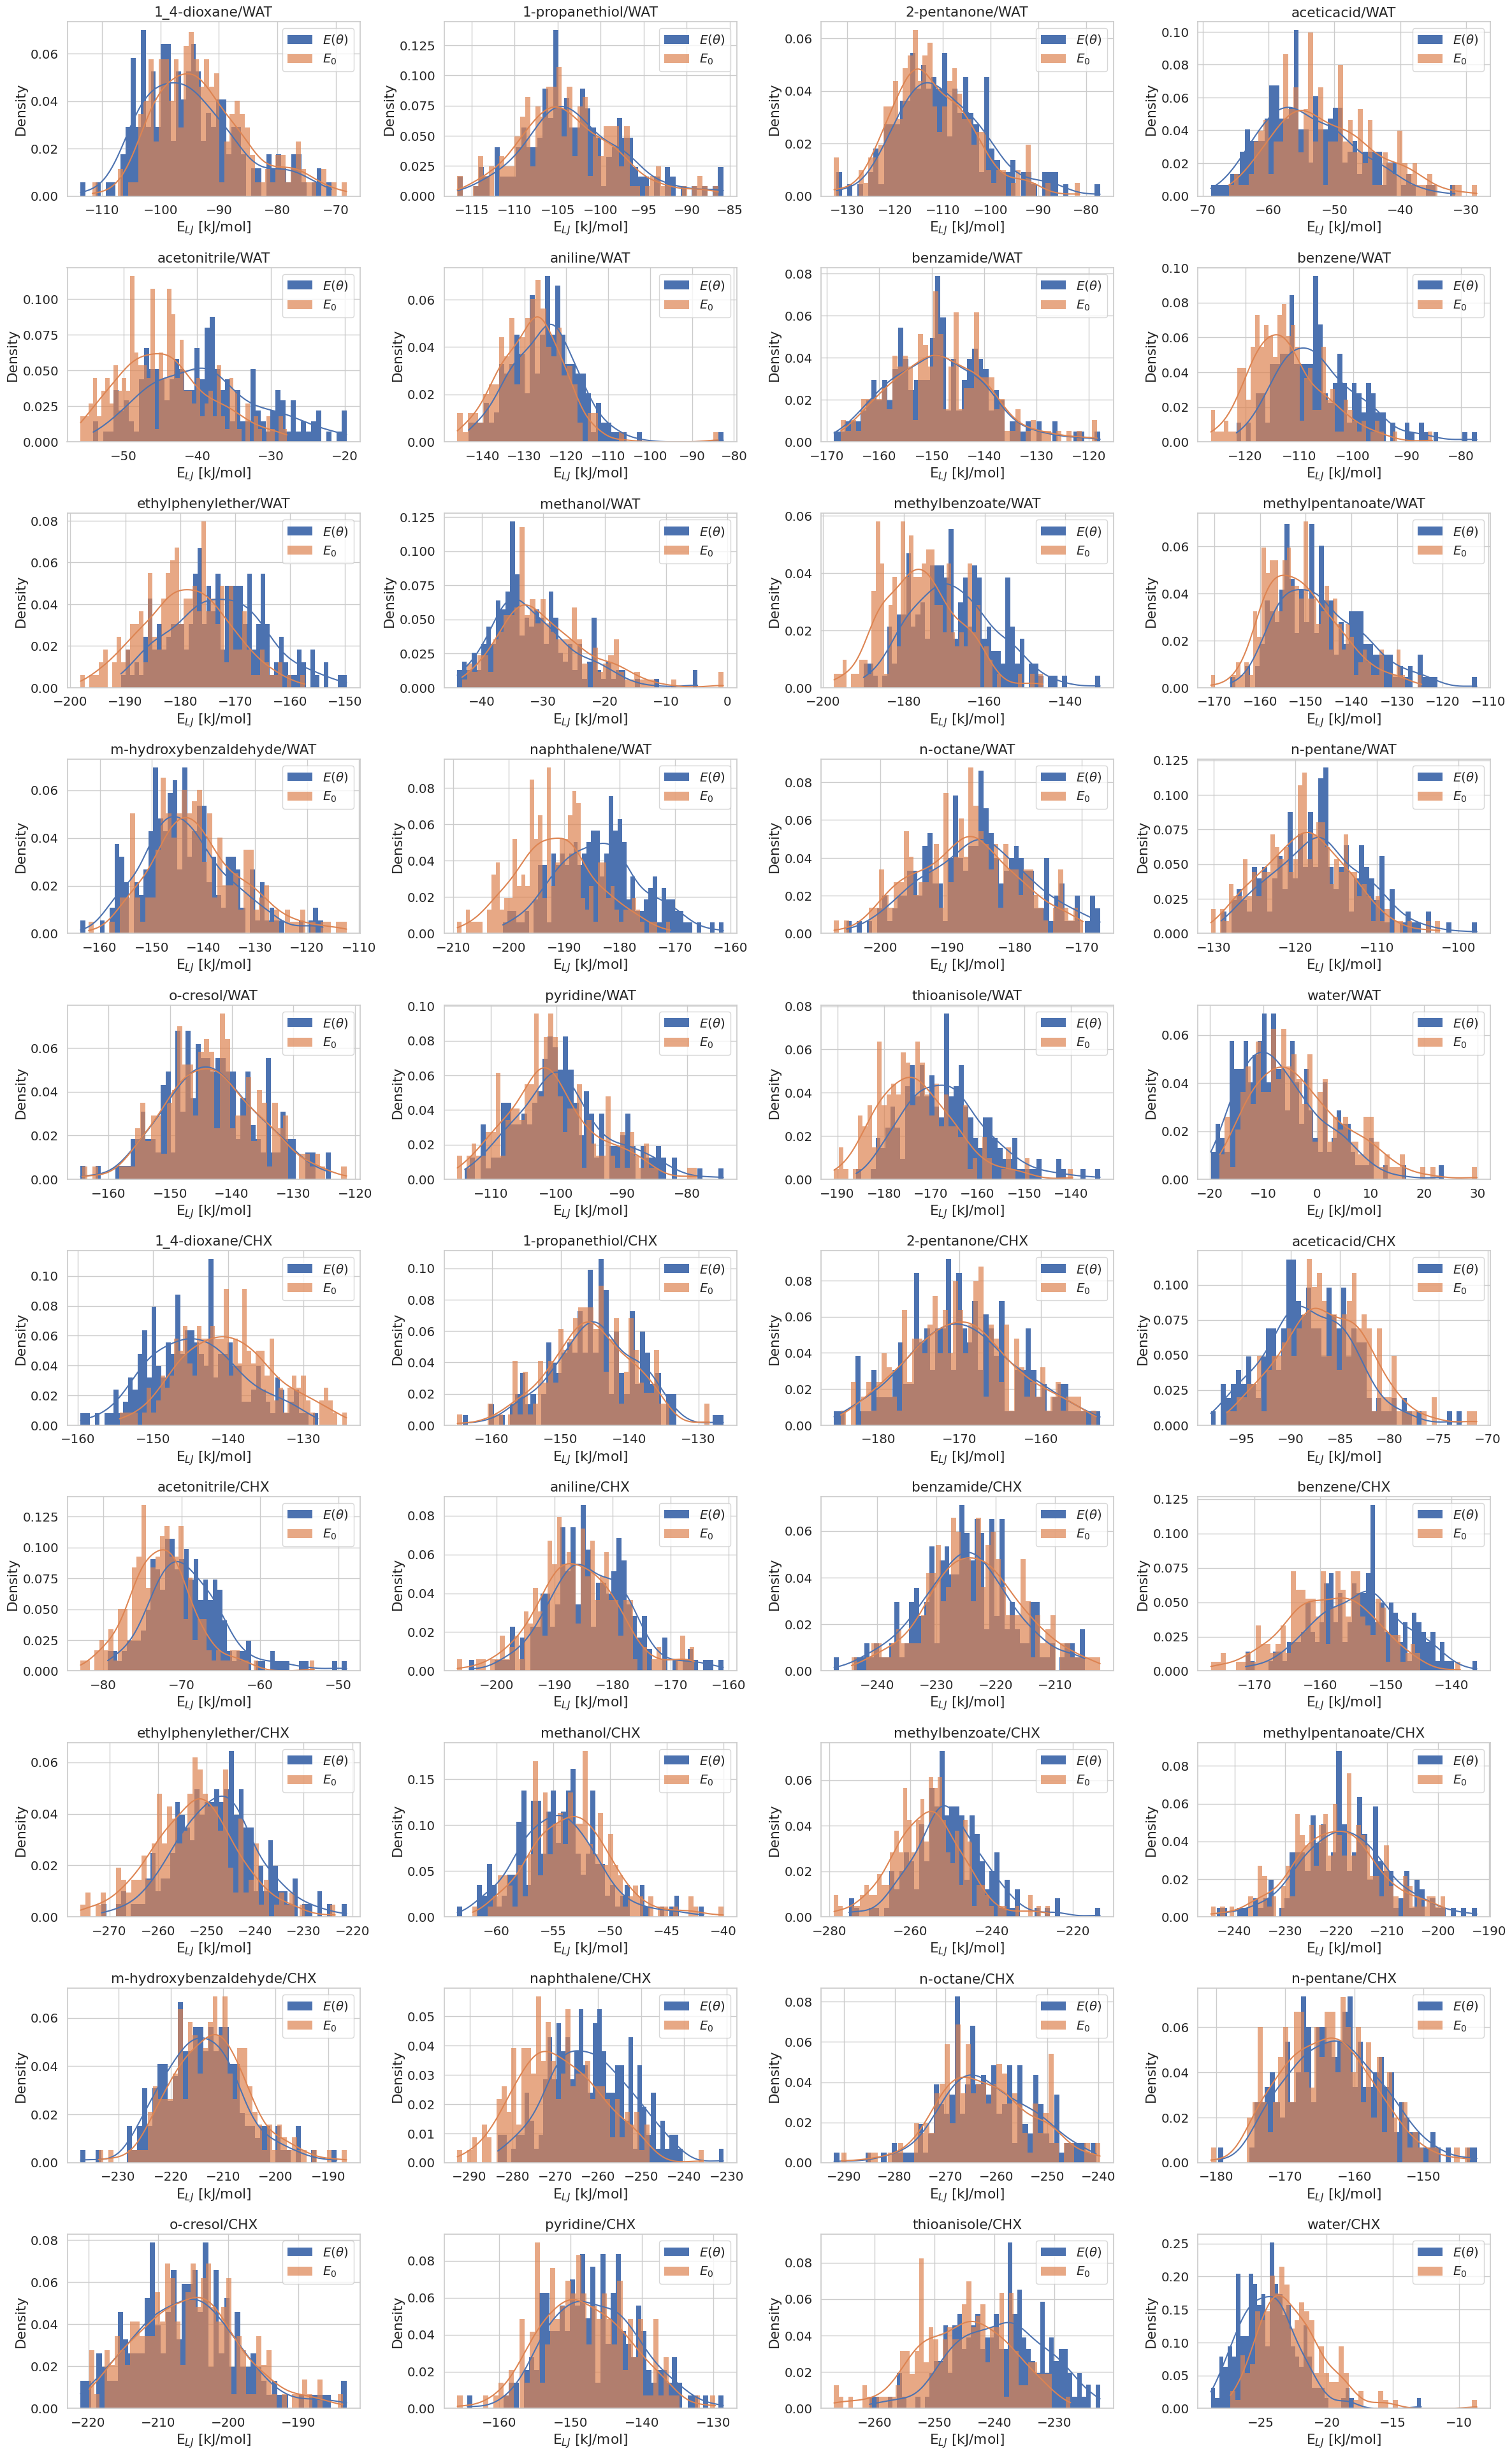

In [24]:
sns.set(style="whitegrid", font_scale=1.3)

num_mols = len(mols_plots)
n_cols = 4
n_rows = math.ceil(num_mols / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, mol in enumerate(mols_plots):
    ax = axes[i]
    sns.histplot(
        e_lj.view(NMOL, -1)[i].detach().cpu() * HARTREE_TO_KJ_MOL,
        bins=50,
        alpha=1,
        stat="density",
        edgecolor=None,
        linewidth=0,
        ax=ax,
        kde=True,
        label=r"$E(\theta)$",
    )
    sns.histplot(
        e_lj_init.view(NMOL, -1)[i].detach().cpu() * HARTREE_TO_KJ_MOL,
        bins=50,
        alpha=0.7,
        stat="density",
        edgecolor=None,
        linewidth=0,
        ax=ax,
        kde=True,
        label=r"$E_0$",
    )
    ax.set_title(mol)
    ax.set_xlabel(r"E$_{LJ}$ [kJ/mol]")
    ax.set_ylabel("Density")
    ax.legend()
    # ax.set_xlim(0, 2)

# Hide unused axes* 1
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("lj_energy_distributions.pdf", dpi=300, bbox_inches="tight")

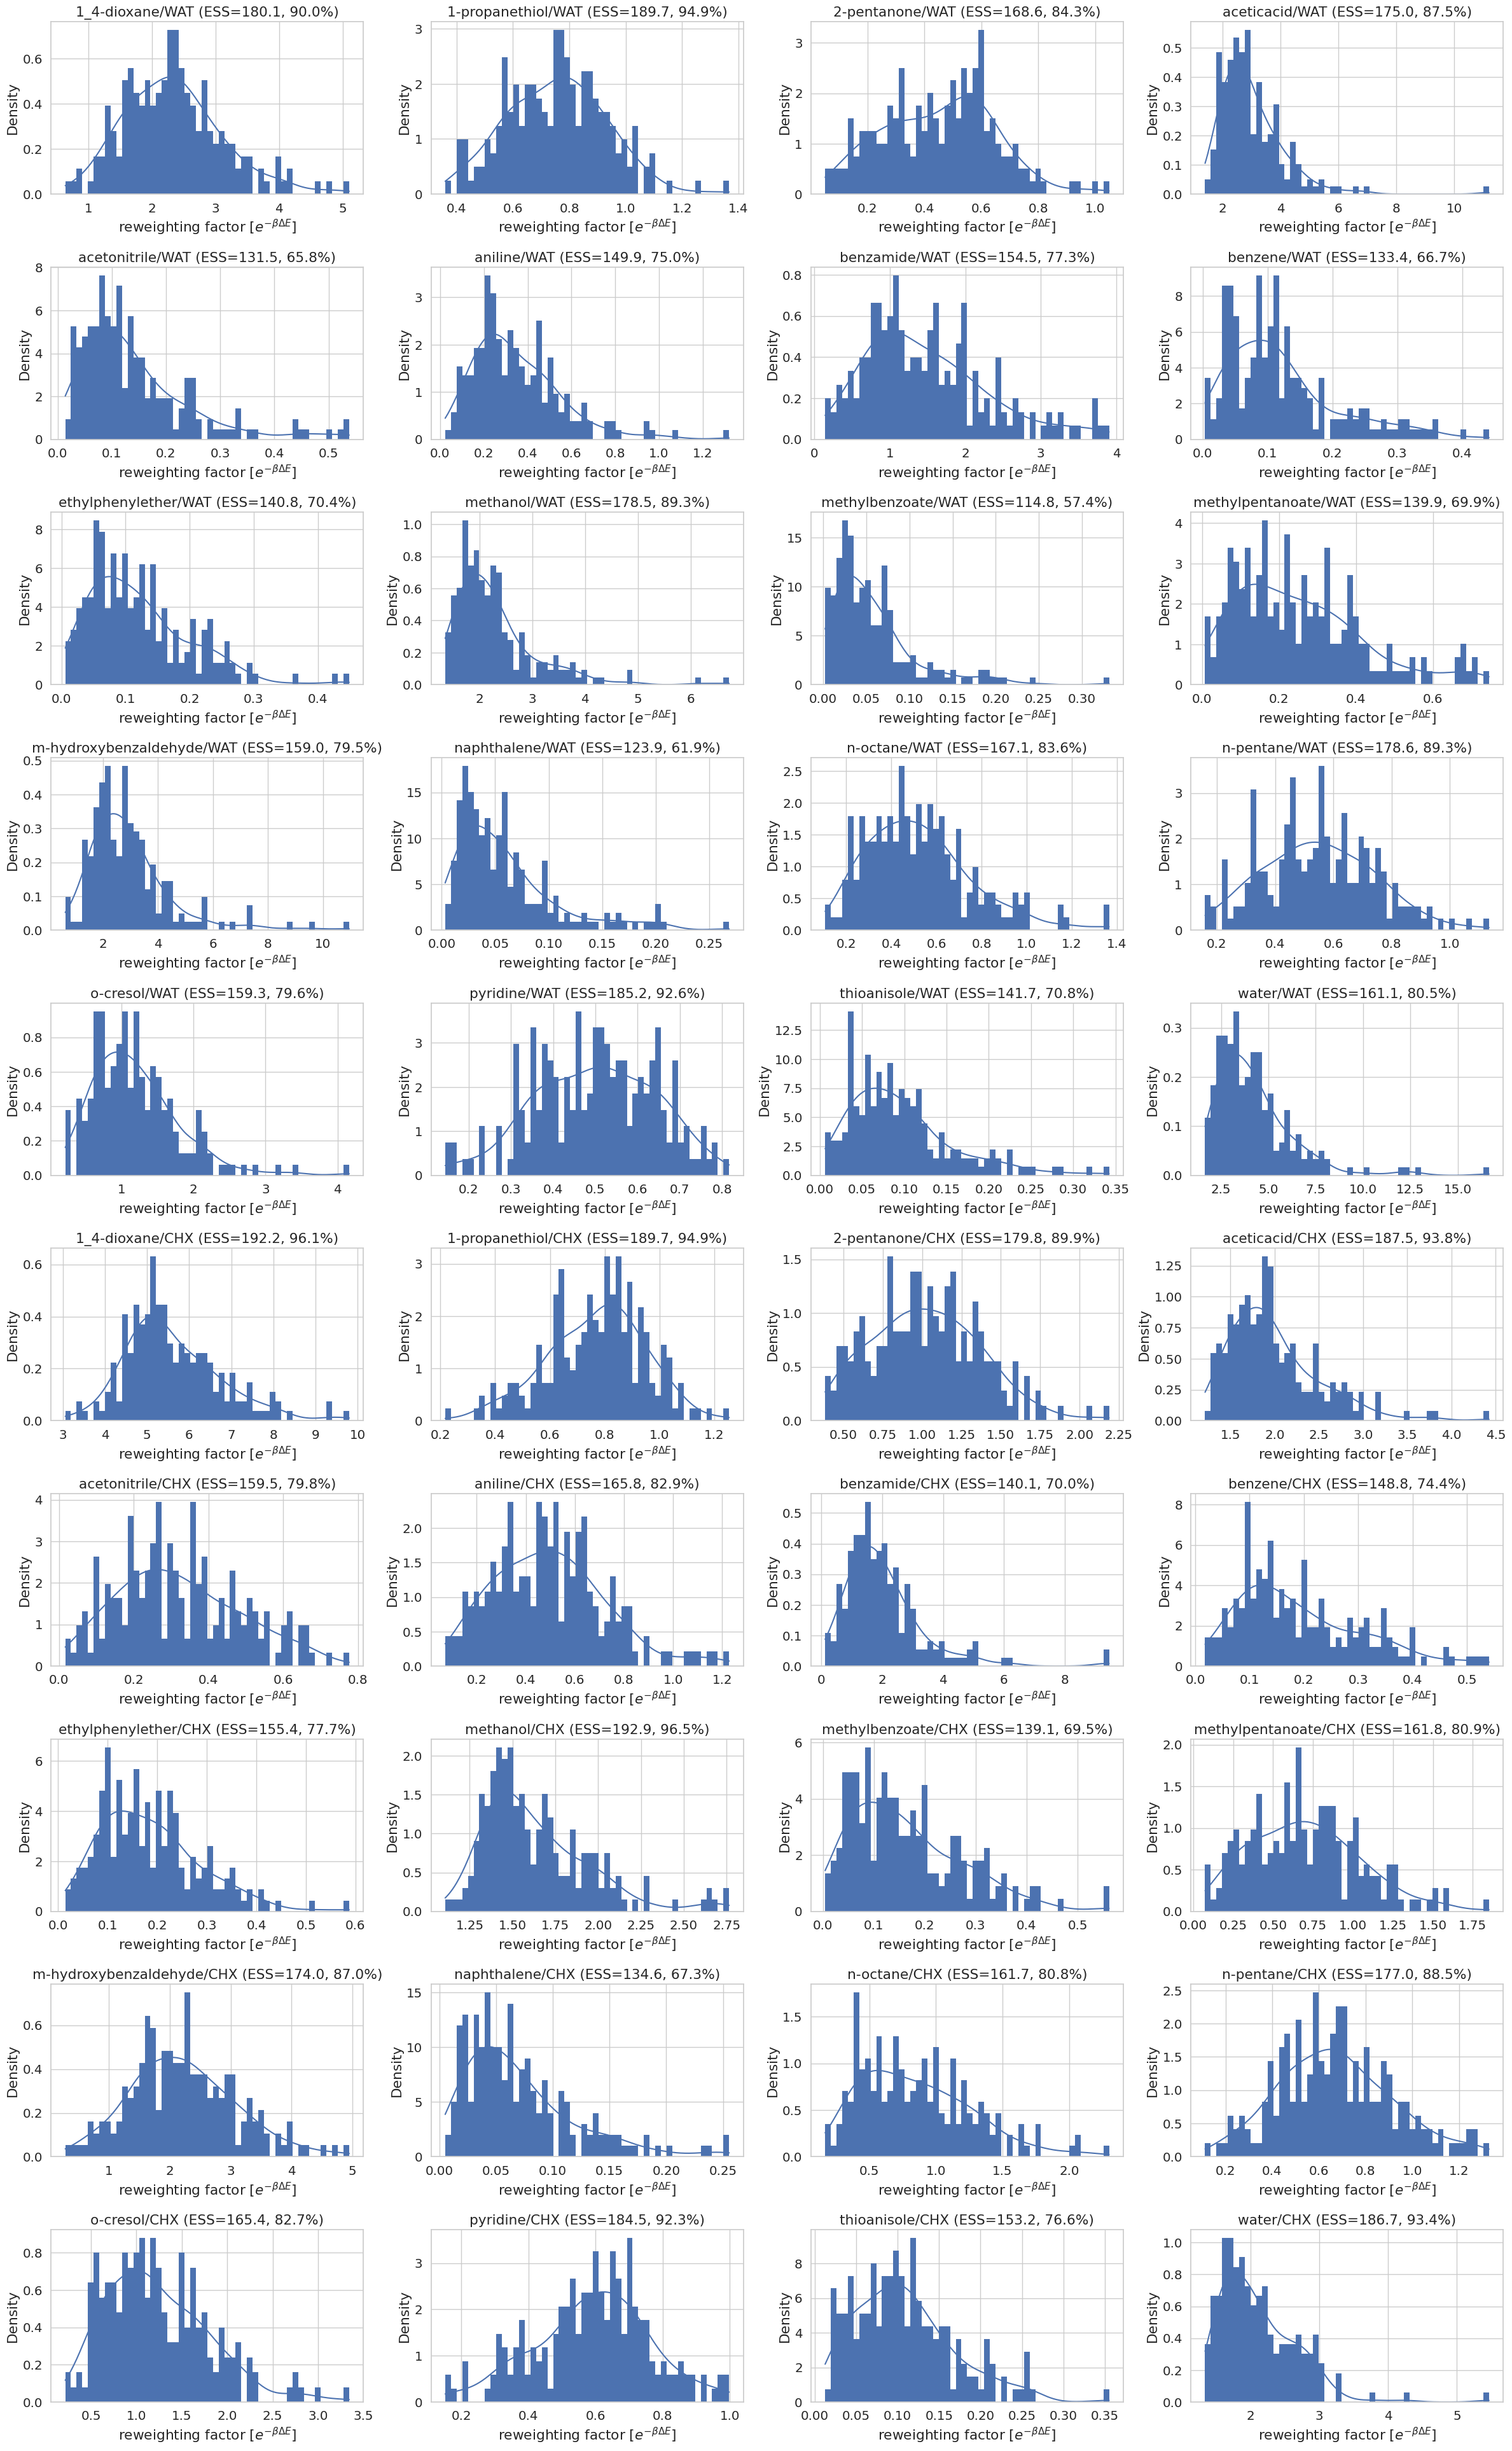

In [25]:
sns.set(style="whitegrid", font_scale=1.3)

num_mols = len(mols_plots)
n_cols = 4
n_rows = math.ceil(num_mols / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

# Calculate weights
w = torch.exp(-beta * (e_lj.view(NMOL, -1) - e_lj_init.view(NMOL, -1)))

# Calculate effective sample size
ess = (w.sum(dim=1) ** 2) / (w.pow(2).sum(dim=1))
perc_ess = ess / w.shape[1] * 100

for i, mol in enumerate(mols_plots):
    ax = axes[i]
    data_block = w[i]
    sns.histplot(
        w[i].detach().cpu(),
        bins=50,
        alpha=1,
        stat="density",
        edgecolor=None,
        linewidth=0,
        ax=ax,
        kde=True,
    )
    ax.set_title(mol + f" (ESS={ess[i]:.1f}, {perc_ess[i]:.1f}%)")
    ax.set_xlabel(r"reweighting factor [$e^{-\beta\Delta E}$]")
    ax.set_ylabel("Density")

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("lj_reweighting_factors.pdf", dpi=300, bbox_inches="tight")

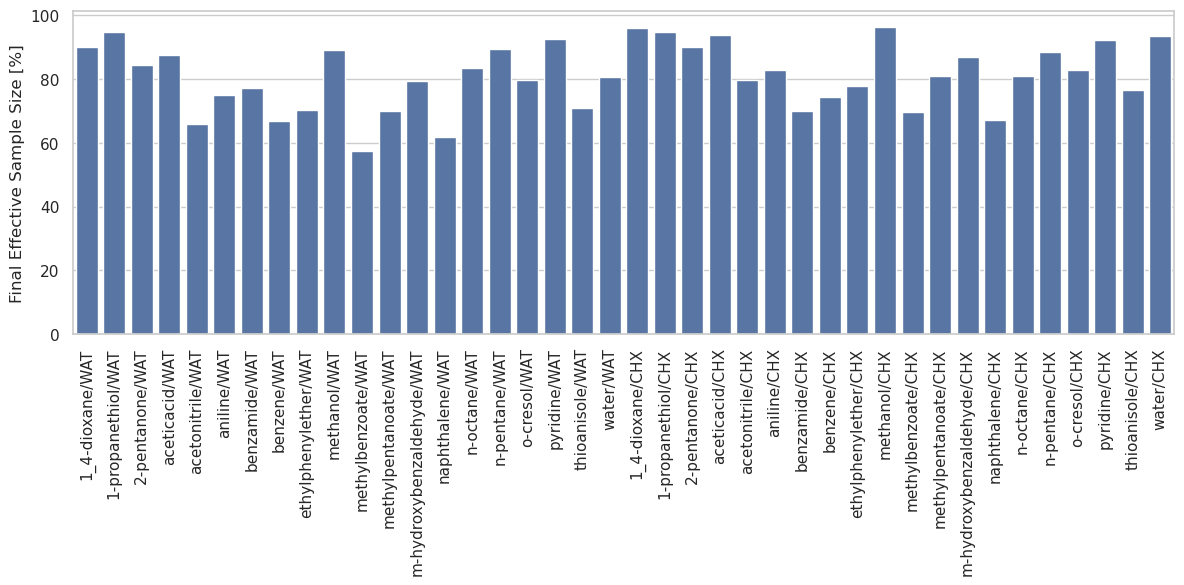

In [26]:
# Plot ESS with x labels as mols_plots
sns.set(style="whitegrid", font_scale=1.0)
fig, ax = plt.subplots(figsize=(12, 6))
ess = (w.sum(dim=1) ** 2) / (w.pow(2).sum(dim=1))
perc_ess = ess / w.shape[1] * 100
sns.barplot(x=mols_plots, y=perc_ess.detach().cpu(), ax=ax)
ax.set_ylabel("Final Effective Sample Size [%]")
ax.tick_params(axis='x', rotation=90)
fig.tight_layout()
plt.savefig("lj_effective_sample_size.pdf", dpi=300, bbox_inches="tight")

# Plots

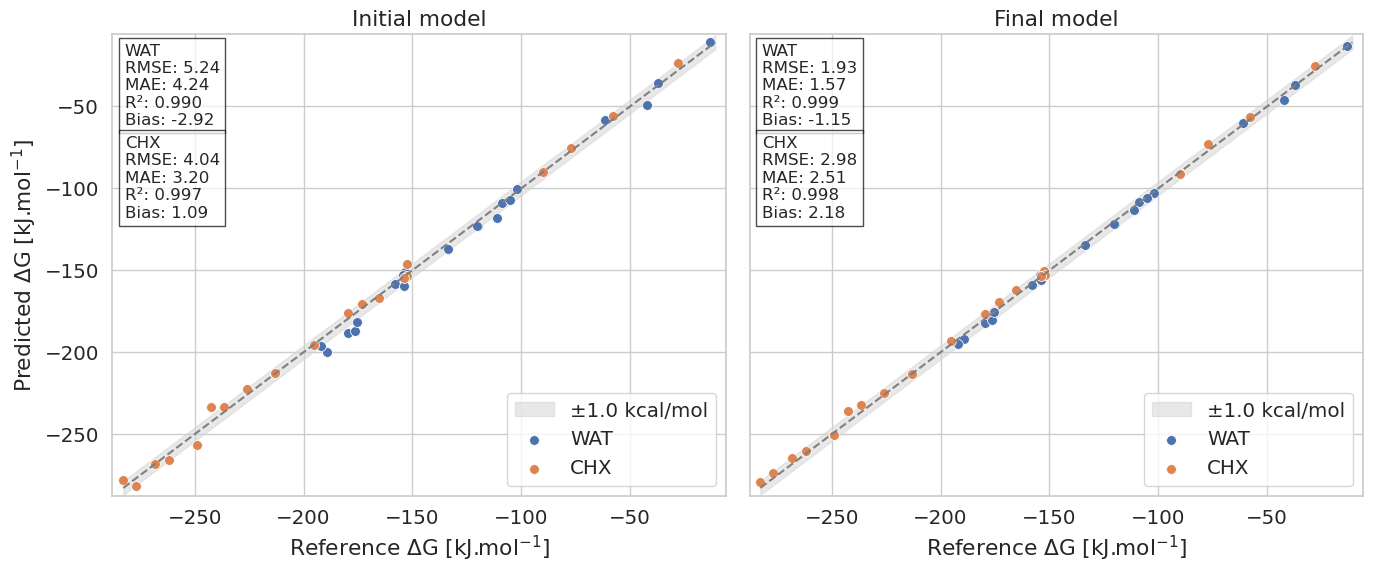

In [27]:
sns.set(style="whitegrid", font_scale=1.3)

dG_lj_calc = dG_lj.detach().cpu().numpy() * HARTREE_TO_KJ_MOL
dG_lj_init_local = dG_lj_init.detach().cpu().numpy() * HARTREE_TO_KJ_MOL
dG_ref = dG_lj_ref.detach().cpu().numpy() * HARTREE_TO_KJ_MOL

min_v = min(dG_ref.min(), dG_lj_calc.min(), dG_lj_init_local.min())
max_v = max(dG_ref.max(), dG_lj_calc.max(), dG_lj_init_local.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Shadow region
for ax in axes:
    ax.fill_between(
        [min_v, max_v],
        [min_v - 4.184, max_v - 4.184],
        [min_v + 4.184, max_v + 4.184],
        color="lightgray",
        alpha=0.5,
        label="±1.0 kcal/mol",
    )

# Final model
ax = axes[1]
sns.scatterplot(x=dG_ref[:20], y=dG_lj_calc[:20], s=50, ax=ax, label="WAT")
sns.scatterplot(x=dG_ref[20:], y=dG_lj_calc[20:], s=50, ax=ax, label="CHX")

ax.plot([min_v, max_v], [min_v, max_v], "--", color="gray", linewidth=1.5)
ax.set_title("Final model")
ax.set_xlabel("Reference ΔG [kJ.mol$^{-1}$]")
ax.set_ylabel("")

for i, m in enumerate(["WAT", "CHX"]):
    rmse = np.sqrt(
        mean_squared_error(
            dG_ref[i * 20 : (i + 1) * 20], dG_lj_calc[i * 20 : (i + 1) * 20]
        )
    )
    mae = mean_absolute_error(
        dG_ref[i * 20 : (i + 1) * 20], dG_lj_calc[i * 20 : (i + 1) * 20]
    )
    r2 = r2_score(dG_ref[i * 20 : (i + 1) * 20], dG_lj_calc[i * 20 : (i + 1) * 20])
    bias = np.mean(dG_lj_calc[i * 20 : (i + 1) * 20] - dG_ref[i * 20 : (i + 1) * 20])
    ax.text(
        0.02,
        0.98 - i * 0.20,
        f"{m}\nRMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.3f}\nBias: {bias:.2f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.7),
    )

# Initial model
ax = axes[0]
sns.scatterplot(x=dG_ref[:20], y=dG_lj_init_local[:20], s=50, ax=ax, label="WAT")
sns.scatterplot(x=dG_ref[20:], y=dG_lj_init_local[20:], s=50, ax=ax, label="CHX")
ax.plot([min_v, max_v], [min_v, max_v], "--", color="gray", linewidth=1.5)
ax.set_title("Initial model")
ax.set_xlabel("Reference ΔG [kJ.mol$^{-1}$]")
ax.set_ylabel("Predicted ΔG [kJ.mol$^{-1}$]")


for i, m in enumerate(["WAT", "CHX"]):
    rmse = np.sqrt(
        mean_squared_error(
            dG_ref[i * 20 : (i + 1) * 20], dG_lj_init_local[i * 20 : (i + 1) * 20]
        )
    )
    mae = mean_absolute_error(
        dG_ref[i * 20 : (i + 1) * 20], dG_lj_init_local[i * 20 : (i + 1) * 20]
    )
    r2 = r2_score(
        dG_ref[i * 20 : (i + 1) * 20], dG_lj_init_local[i * 20 : (i + 1) * 20]
    )
    bias = np.mean(
        dG_lj_init_local[i * 20 : (i + 1) * 20] - dG_ref[i * 20 : (i + 1) * 20]
    )
    ax.text(
        0.02,
        0.98 - i * 0.20,
        f"{m}\nRMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.3f}\nBias: {bias:.2f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="black", alpha=0.7),
    )

plt.xlim(min_v - 5, max_v + 5)
plt.ylim(min_v - 5, max_v + 5)

plt.tight_layout()
plt.savefig("lj_dG_comparison.pdf", dpi=300, bbox_inches="tight")

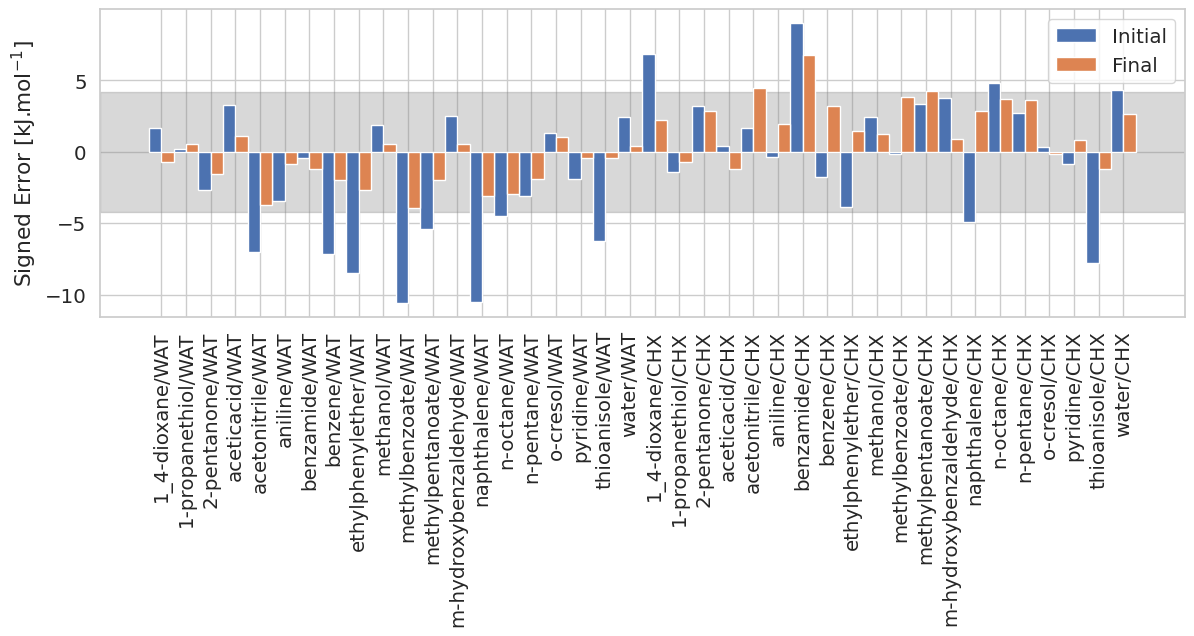

In [28]:
sns.set(style="whitegrid", font_scale=1.3)
fig, ax = plt.subplots(1, 1, figsize=(14, 4))

initial_signed_errors = dG_lj_init_local - dG_ref
final_signed_errors = dG_lj_calc - dG_ref
x = np.arange(len(mols_plots))
width = 0.5

ax.axhspan(-4.184, 4.184, color="gray", alpha=0.3)
bars1 = ax.bar(x - width / 2, initial_signed_errors, width, label="Initial")
bars2 = ax.bar(x + width / 2, final_signed_errors, width, label="Final")

ax.set_xticks(x)
ax.set_xticklabels(mols_plots, rotation=90)
ax.set_ylabel("Signed Error [kJ.mol$^{-1}$]")
ax.legend()
plt.savefig("lj_signed_errors.pdf", dpi=300, bbox_inches="tight")

#### Scaling of C6 coefficients

tensor([1.0030, 1.0018, 1.0008, 1.0020, 0.9998], device='cuda:0',
       grad_fn=<DivBackward0>)


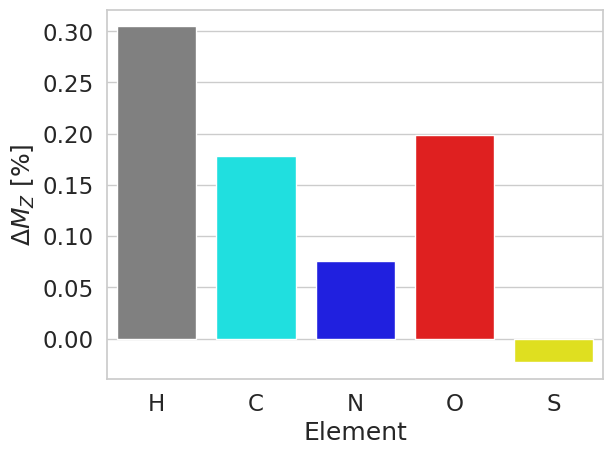

In [29]:
sns.set_context("notebook", font_scale=1.5)
c6_Z = (emle_base.c6_Z - c6_Z_init) / (c6_Z_init.abs() + 1e-16) * 100
print(emle_base.c6_Z / c6_Z_init)
values = c6_Z.tolist() if torch.is_tensor(c6_Z) else list(c6_Z)
elements = ["H", "C", "N", "O", "S"]
colors = ["grey", "cyan", "blue", "red", "yellow"]
sns.barplot(x=elements, y=values, palette=colors)
plt.xlabel("Element")
plt.ylabel(r"$\Delta M_{Z}$ [%]")
plt.savefig("lj_m_Z_changes.pdf", dpi=300, bbox_inches="tight")

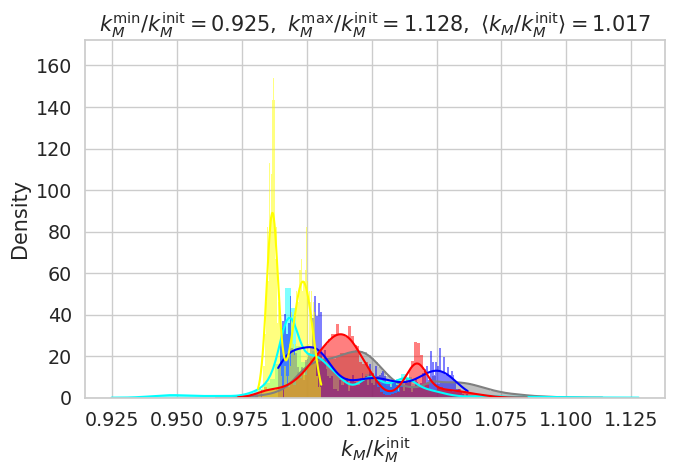

In [30]:
sns.set(style="whitegrid", font_scale=1.25)
z_colors = {
    1: "grey",
    6: "cyan",
    7: "blue",
    8: "red",
    16: "yellow",
}
plt.figure(figsize=(7, 5))
arr = torch.where(c6_qm_init > 0, c6_qm / c6_qm_init, 0.0)
for color in z_colors.keys():
    mask_elem = (z == color) & (arr != 0.0)
    sns.histplot(
        arr[mask_elem].detach().cpu(),
        bins=100,
        alpha=0.5,
        stat="density",
        edgecolor=None,
        linewidth=0,
        kde=True,
        label=f"Z={color}",
        color=z_colors[color],
    )

plt.ylabel("Density")
plt.title(
    r"$k_{M}^{\min}/k_{M}^{\rm init} = "
    f"{arr[arr != 0.0].min().item():.3f},\ "
    r"k_{M}^{\max}/k_{M}^{\rm init} = "
    f"{arr[arr != 0.0].max().item():.3f},\ "
    r"\langle k_{M}/k_{M}^{\rm init} \rangle = "
    f"{arr[arr != 0.0].mean().item():.3f}$"
)
plt.xlabel(r"$k_{M}/k_{M}^{\rm init}$")

# plt.xlim(0.8, 1.2)
plt.tight_layout()
plt.savefig("lj_k_M_changes.pdf", dpi=300, bbox_inches="tight")

Sigma scale min/max values: 0.924802839756012 1.1278307437896729


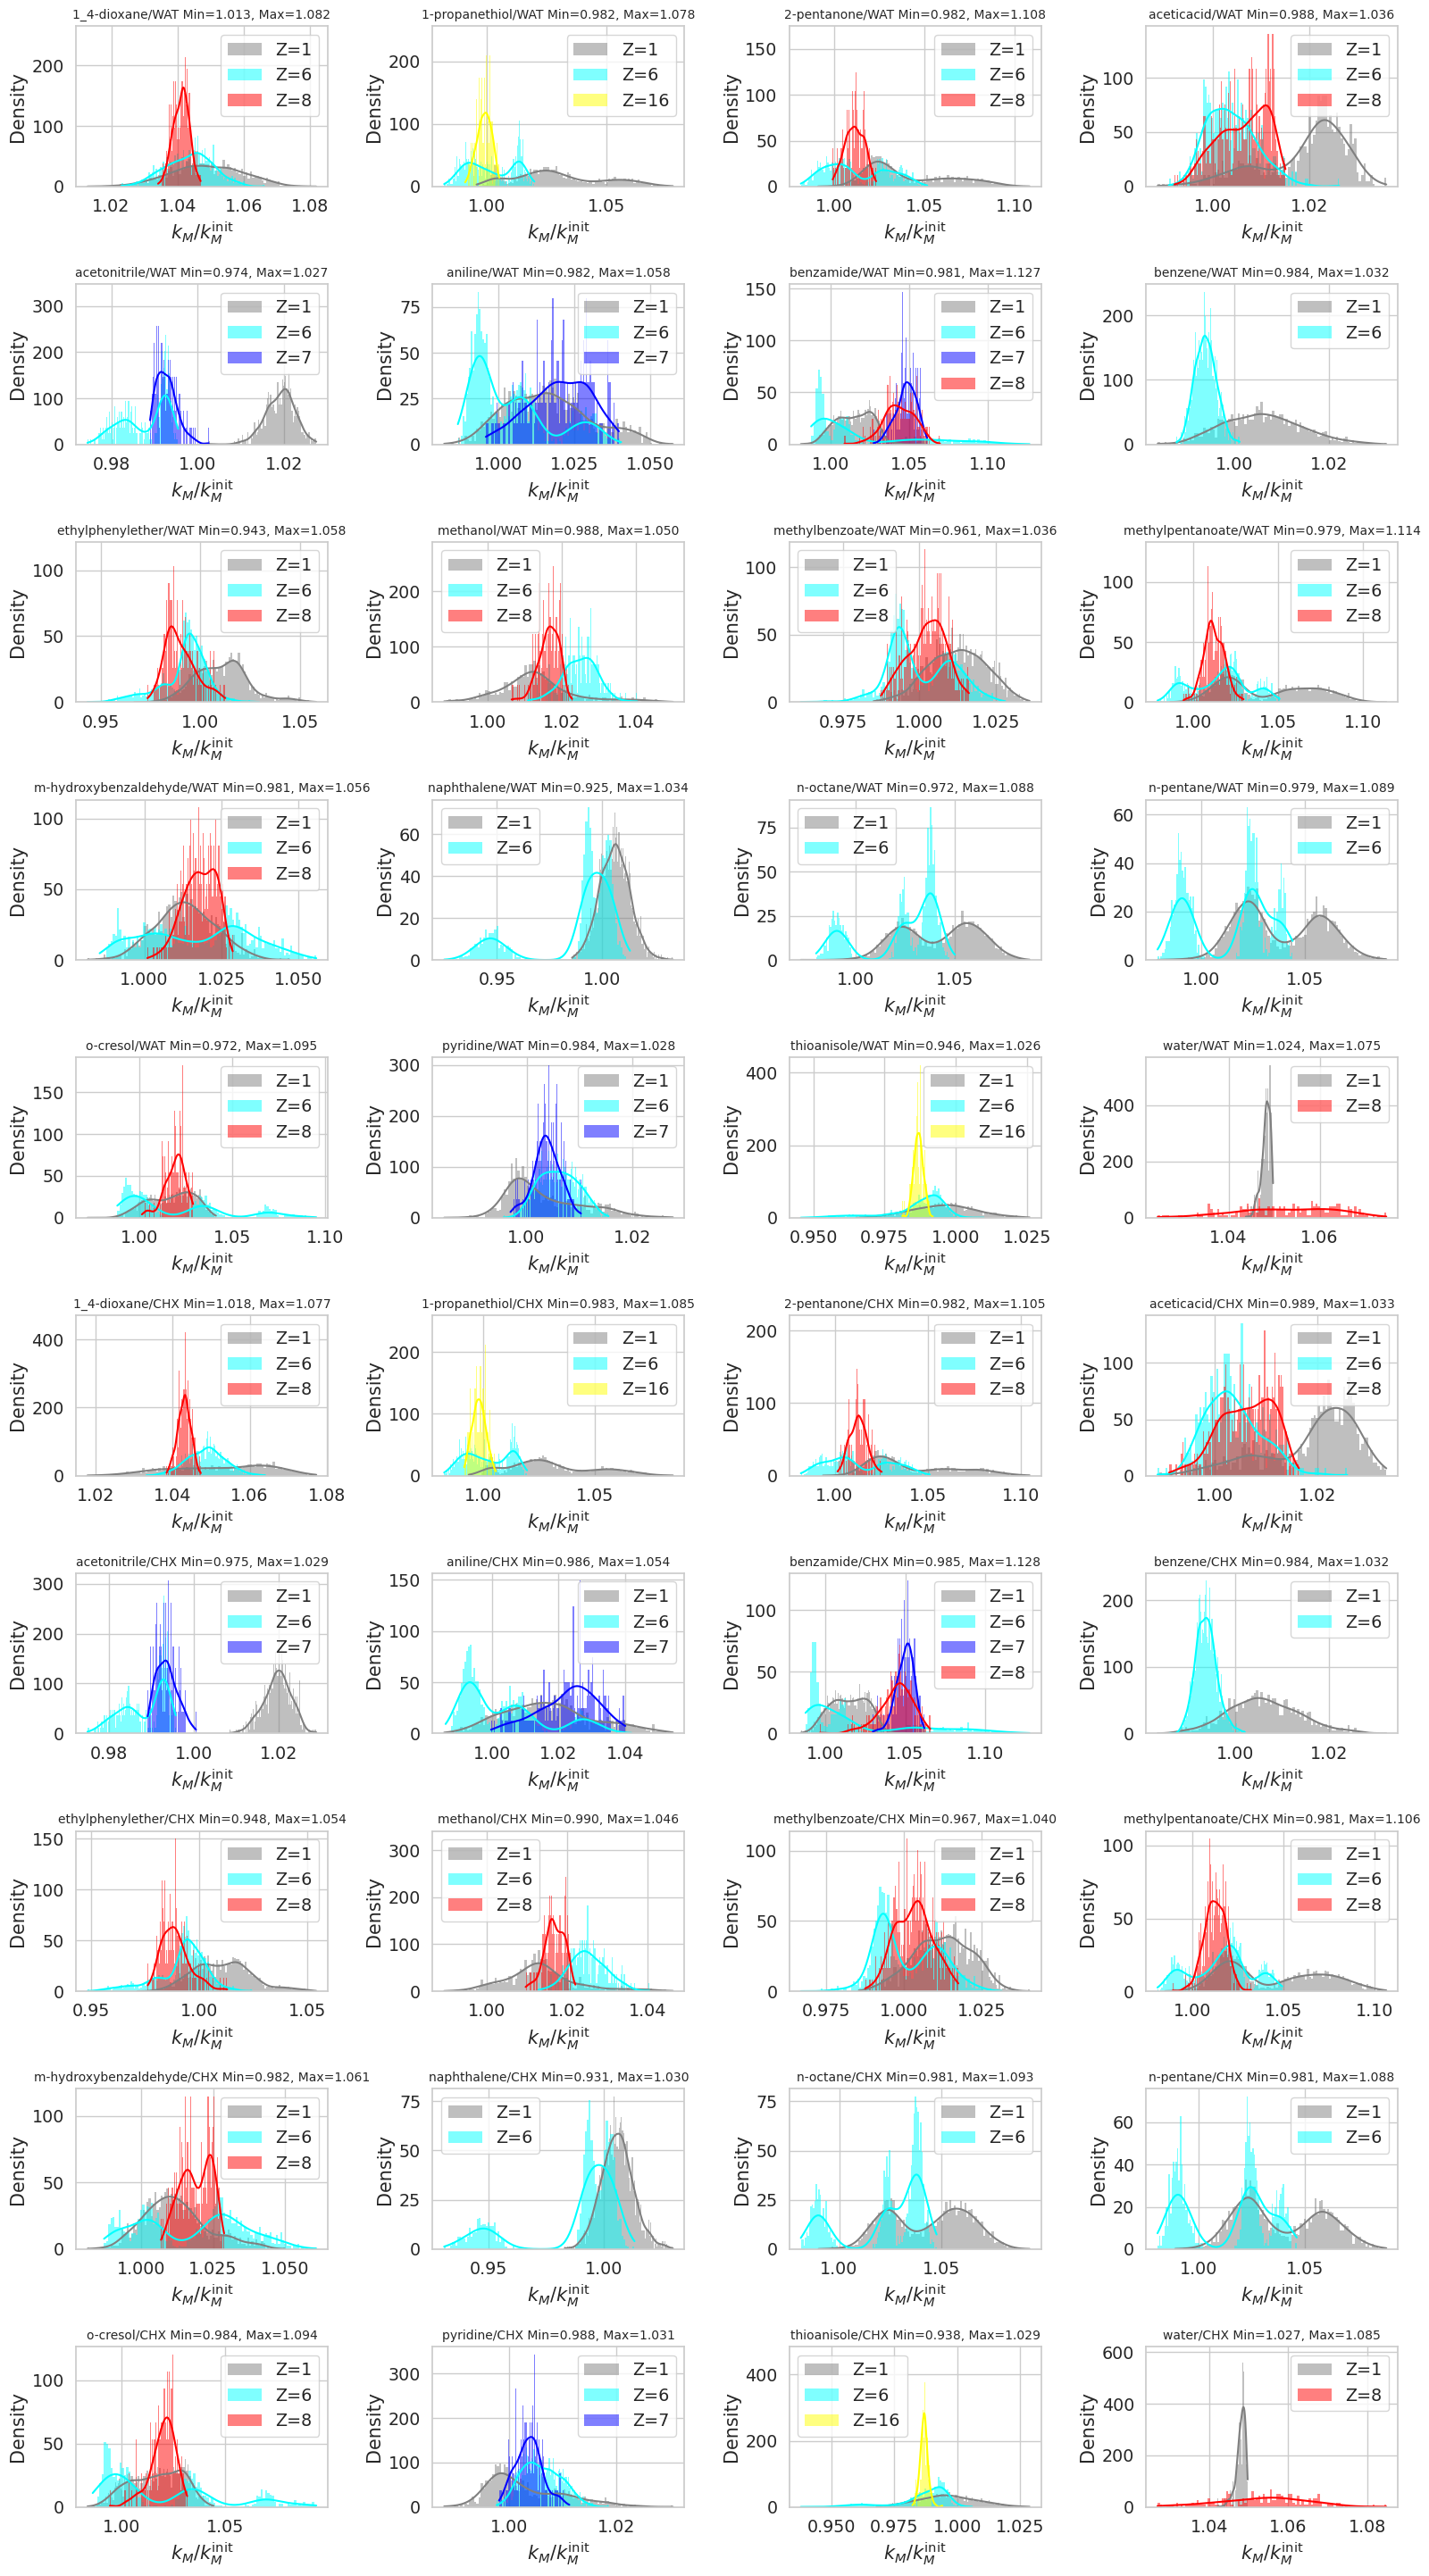

In [31]:
sigma_scale = torch.where(c6_qm_init > 0, c6_qm / c6_qm_init, 0.0)

chunk_size = int(sigma_scale.shape[0] / len(mols_plots))
num_mols = len(mols_plots)
n_cols = 4
n_rows = math.ceil(num_mols / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

print(
    "Sigma scale min/max values:",
    sigma_scale[sigma_scale != 0.0].min().item(),
    sigma_scale[sigma_scale != 0.0].max().item(),
)

for i, mol in enumerate(mols_plots):
    ax = axes[i]
    data_block = sigma_scale[i * chunk_size : (i + 1) * chunk_size, :]

    for color in z_colors.keys():
        mask_elem = (z[i * chunk_size : (i + 1) * chunk_size, :] == color) & (
            data_block != 0.0
        )
        sns.histplot(
            data_block[mask_elem].detach().cpu(),
            bins=100,
            alpha=0.5,
            stat="density",
            edgecolor=None,
            linewidth=0,
            ax=ax,
            kde=True,
            label=f"Z={color}",
            color=z_colors[color],
        )
    ax.legend()
    ax.set_title(
        mol + f" Min={data_block[data_block != 0.0].min().item():.3f}, Max={data_block[data_block != 0.0].max().item():.3f}",
        fontsize=10,
    )
    ax.set_xlabel(r"$k_{M}/k_{M}^{\rm init}$")
    ax.set_ylabel("Density")

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("lj_k_M_distribution.pdf", dpi=300, bbox_inches="tight")

Sigma scale min/max values: 0.939516544342041 1.0991156101226807


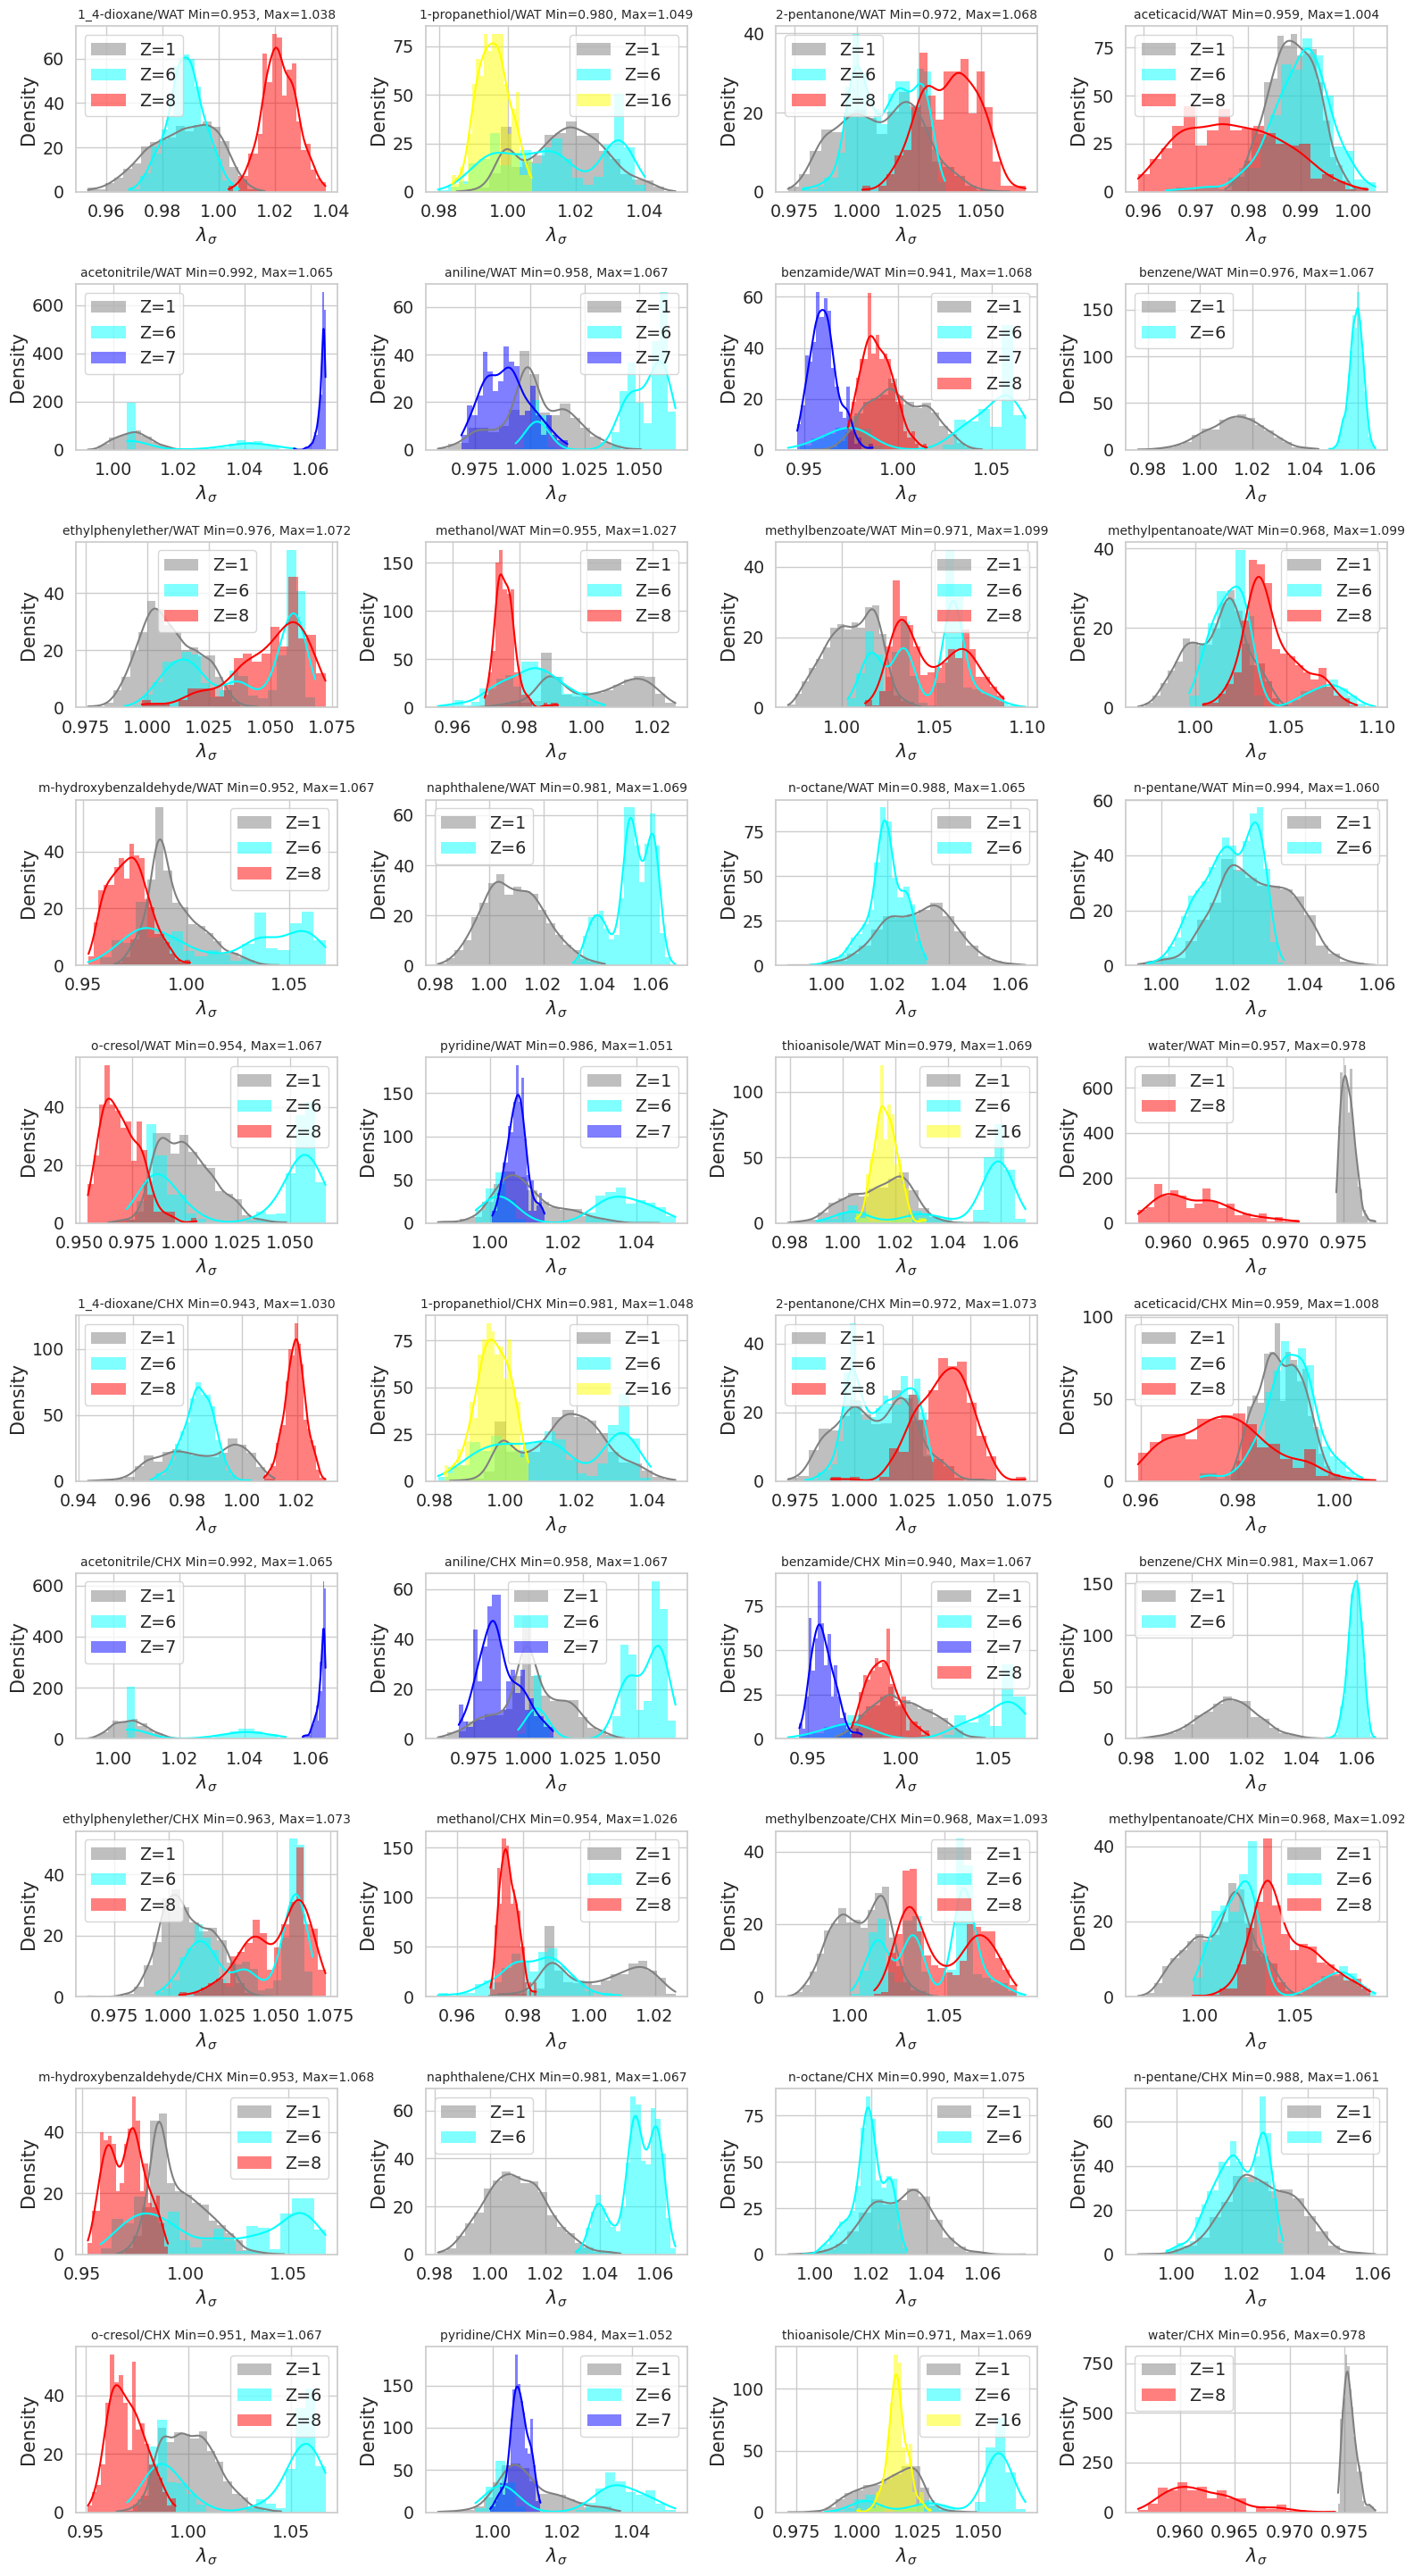

In [32]:
z_colors = {
    1: "grey",
    6: "cyan",
    7: "blue",
    8: "red",
    16: "yellow",
}

sigma_scale = sigma_scale_qm

chunk_size = int(sigma_scale.shape[0] / len(mols_plots))
num_mols = len(mols_plots)
n_cols = 4
n_rows = math.ceil(num_mols / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

print(
    "Sigma scale min/max values:",
    sigma_scale[sigma_scale != 0.0].min().item(),
    sigma_scale[sigma_scale != 0.0].max().item(),
)

for i, mol in enumerate(mols_plots):
    ax = axes[i]
    data_block = sigma_scale[i * chunk_size : (i + 1) * chunk_size, :]

    for color in z_colors.keys():
        mask_elem = (z[i * chunk_size : (i + 1) * chunk_size, :] == color) & (
            data_block != 0.0
        )
        sns.histplot(
            data_block[mask_elem].detach().cpu(),
            bins=20,
            alpha=0.5,
            stat="density",
            edgecolor=None,
            linewidth=0,
            ax=ax,
            kde=True,
            label=f"Z={color}",
            color=z_colors[color],
        )
    ax.legend()
    ax.set_title(
        mol
        + f" Min={data_block[data_block != 0.0].min().item():.3f}, Max={data_block.max().item():.3f}",
        fontsize=10,
    )
    ax.set_xlabel(r"$\lambda_{\sigma}$")
    ax.set_ylabel("Density")
    # ax.set_xlim(0.8, 1.2)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("lj_sigma_scale_distribution.pdf", dpi=300, bbox_inches="tight")

Sigma scale min/max values: 0.939516544342041 1.0991156101226807


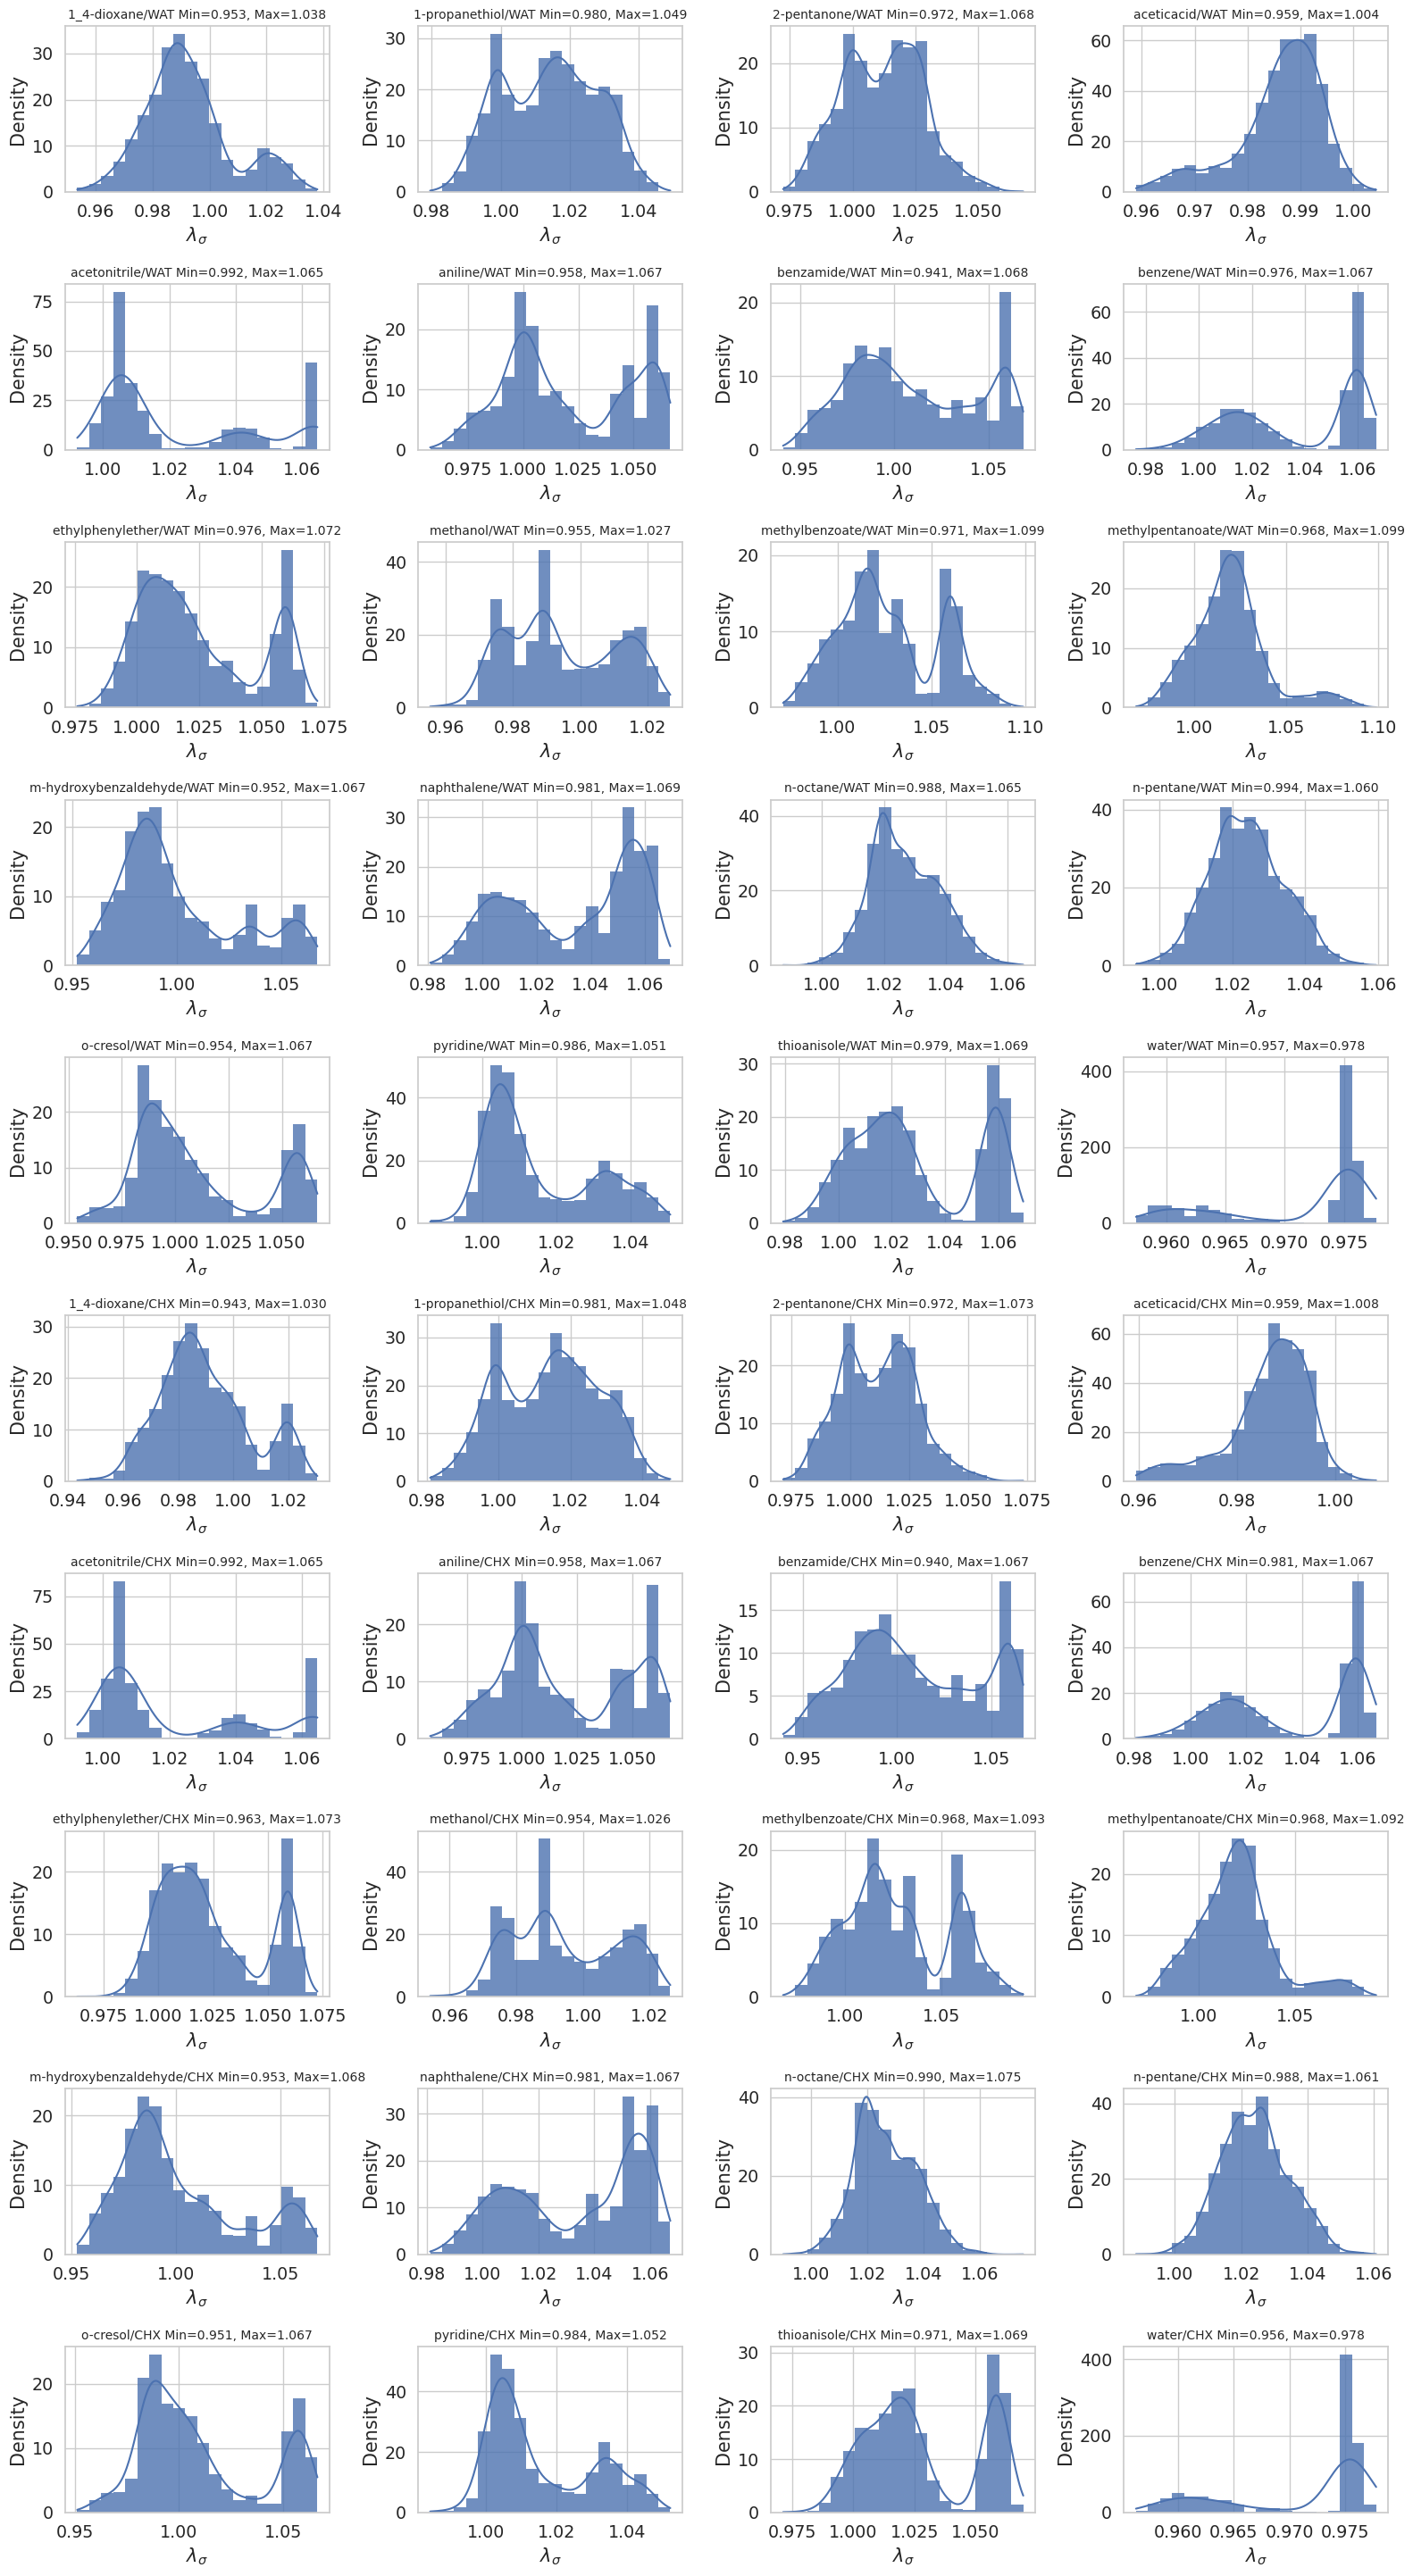

In [33]:
sigma_scale = sigma_scale_qm

chunk_size = int(sigma_scale.shape[0] / len(mols_plots))
num_mols = len(mols_plots)
n_cols = 4
n_rows = math.ceil(num_mols / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

print(
    "Sigma scale min/max values:",
    sigma_scale[sigma_scale != 0.0].min().item(),
    sigma_scale[sigma_scale != 0.0].max().item(),
)

for i, mol in enumerate(mols_plots):
    ax = axes[i]
    data_block = sigma_scale[i * chunk_size : (i + 1) * chunk_size, :]
    mask = data_block != 0.0
    data_block = data_block[mask].flatten()
    sns.histplot(
        data_block.detach().cpu(),
        bins=20,
        alpha=0.8,
        stat="density",
        edgecolor=None,
        linewidth=0,
        ax=ax,
        kde=True,
    )
    ax.set_title(
        mol + f" Min={data_block.min().item():.3f}, Max={data_block.max().item():.3f}",
        fontsize=10,
    )
    ax.set_xlabel(r"$\lambda_{\sigma}$")
    ax.set_ylabel("Density")
    # ax.set_xlim(0.8, 1.2)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("lj_sigma_scale_distribution_all.pdf", dpi=300, bbox_inches="tight")

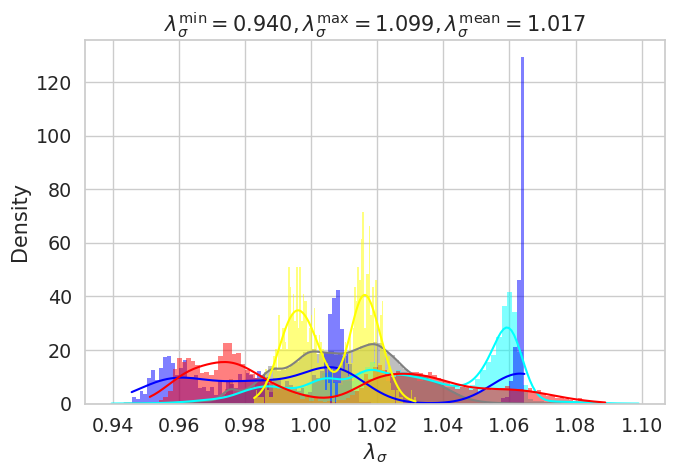

In [34]:
sns.set(style="whitegrid", font_scale=1.25)

plt.figure(figsize=(7, 5))

for color in z_colors.keys():
    mask_elem = (z == color) & (sigma_scale != 0.0)
    sns.histplot(
        sigma_scale[mask_elem].detach().cpu(),
        bins=100,
        alpha=0.5,
        stat="density",
        edgecolor=None,
        linewidth=0,
        kde=True,
        label=f"Z={color}",
        color=z_colors[color],
    )

plt.xlabel(r"$\lambda_{\sigma}$")
plt.ylabel("Density")
plt.title(
    rf"$\lambda_{{\sigma}}^{{\mathrm{{min}}}} = {sigma_scale[sigma_scale != 0.0].min().item():.3f}, "
    rf"\lambda_{{\sigma}}^{{\mathrm{{max}}}} = {sigma_scale.max().item():.3f}, "
    rf"\lambda_{{\sigma}}^{{\mathrm{{mean}}}} = {sigma_scale[sigma_scale != 0.0].mean().item():.3f}$"
)
# plt.xlim(0.8, 1.2)
plt.tight_layout()
plt.savefig("lj_sigma_scale_distribution_overall.pdf", dpi=300, bbox_inches="tight")